# Setup

In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from ydata_profiling import ProfileReport

df = pd.read_csv("Train_Data.csv")
TARGET = "Dropped_Course"
baseline_rate = df[TARGET].mean()
print(df.shape)
print(f"overall {TARGET} rate: {baseline_rate:.4f}")

## Part A - EDA, Missing values

## Profiling Report - Feature Exploration

In [ ]:
profile = ProfileReport(df, title="Train_Data Profiling Report", explorative=True)
profile.to_notebook_iframe()

## Numerical variables

### Prev_Course_Dropouts

count    63464.000000
mean         0.095991
std          0.448526
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: Prev_Course_Dropouts, dtype: float64


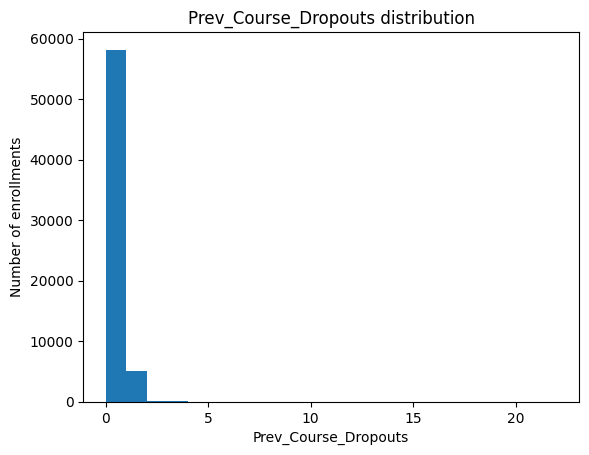

                          mean  count   pct
Prev_Course_Dropouts                       
0                     0.366046  58184  91.7
1                     0.974430   5084   8.0
2                     0.153846     65   0.1
3                     0.122449     49   0.1
4                     0.083333     12   0.0
5                     0.090909     11   0.0
6                     0.636364     11   0.0
11                    0.285714     35   0.1
13                    0.916667     12   0.0
21                    1.000000      1   0.0


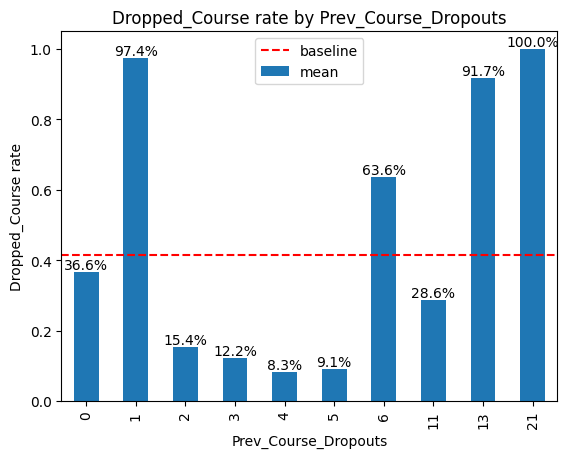

In [47]:
col = "Prev_Course_Dropouts"
print(df[col].describe())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Prev_Course_Dropouts`?**

1. `0` and `1` together account for 99.7% of rows (n=58,184 and n=5,084 respectively). The remaining values (2–21) total only n=196, split across 8 sparse bins — not statistically meaningful on their own.
2. The drop rate nearly triples between these two dominant values: 36.6% at `0` vs. 97.4% at `1`. This is the effect that matters for the analysis.

**Decision:** treat `Prev_Course_Dropouts` as informative only at `0` vs. `1`; exclude rows with values ≥2 from any effect estimate involving this variable, since n=196 is too small to support a reliable per-value rate.

### Prev_Course_Attended

count    63464.000000
mean         0.122967
std          1.535201
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         61.000000
Name: Prev_Course_Attended, dtype: float64
missing: 0


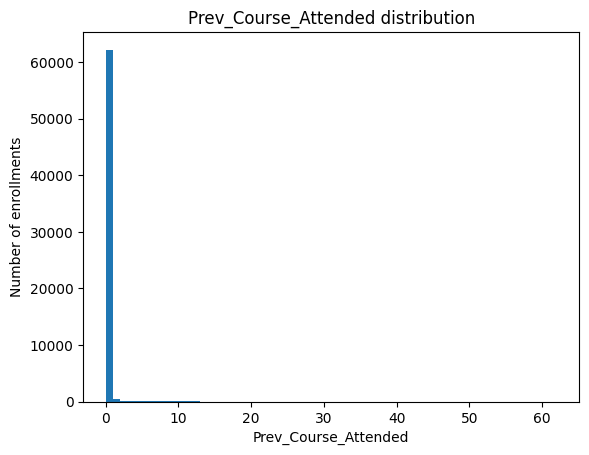

                          mean  count   pct
Prev_Course_Attended                       
0                     0.421384  62188  98.0
1                     0.068085    470   0.7
2                     0.058065    155   0.2
3                     0.056604    106   0.2
4                     0.096386     83   0.1
...                        ...    ...   ...
57                    0.000000      1   0.0
58                    0.500000      2   0.0
59                    0.000000      1   0.0
60                    0.000000      1   0.0
61                    0.000000      1   0.0

[62 rows x 3 columns]

0 vs 1+ grouped:
                          mean  count   pct
Prev_Course_Attended                       
False                 0.421384  62188  98.0
True                  0.073668   1276   2.0


In [48]:
col = "Prev_Course_Attended"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

has_attended = (df[col] > 0)
grouped = df.groupby(has_attended)[TARGET].agg(["mean", "count"])
grouped["pct"] = (grouped["count"] / len(df) * 100).round(1)
print("\n0 vs 1+ grouped:")
print(grouped)

**What can you infer about `Prev_Course_Attended`?**
1. Similar logic to `Prev_Course_Dropouts`: 98% of clients have a value of `0`. The remaining 2% are spread thin across 61 distinct values, many with n<5.
2. Drop rate falls from 42.1% to 7.4% once a client has attended at least one prior course — having attended before is strongly protective, making a client far less likely to drop.

**Decision:** treat `Prev_Course_Attended` as informative only at `0` vs. `1+`, same split logic as `Prev_Course_Dropouts`.

### Registration_Days_Before

count    60798.000000
mean       102.894470
std        109.178824
min          0.000000
25%         19.000000
50%         65.000000
75%        150.000000
max        629.000000
Name: Registration_Days_Before, dtype: float64
missing: 2666 (4.20%)


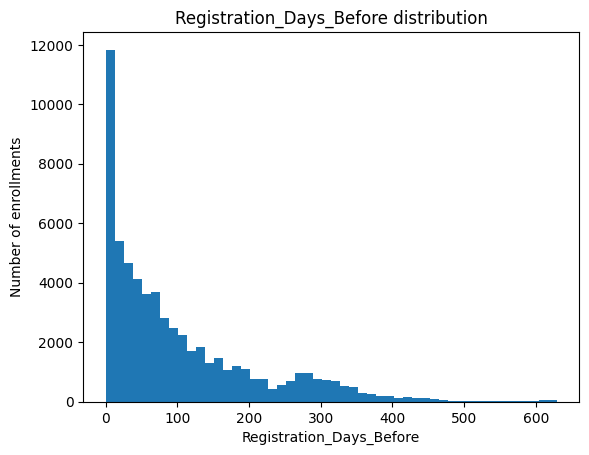

/var/folders/dr/27_gtzy14b3cd8jgjvglzyv00000gn/T/ipykernel_31999/2804895189.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])


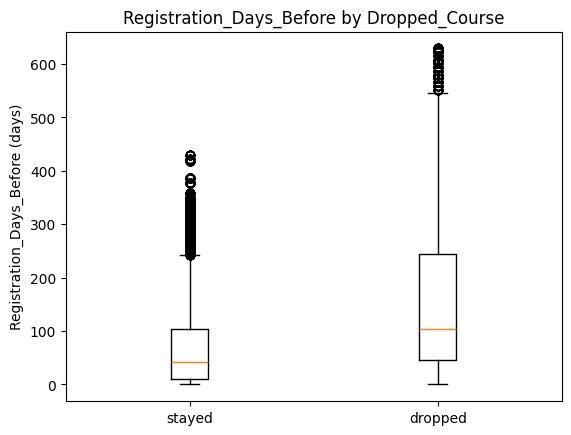

stayed: {'mean': 70.64140875133404, '50%': 43.0}
dropped: {'mean': 148.48046999047315, '50%': 104.0}
               mean  count   pct
has value  0.414356  60798  95.8
missing    0.415229   2666   4.2


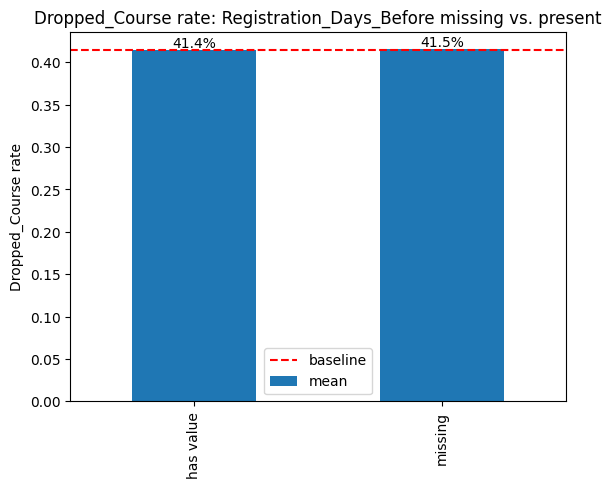

In [49]:
col = "Registration_Days_Before"
print(df[col].describe())
print("missing:", df[col].isna().sum(), f"({df[col].isna().mean():.2%})")

plt.hist(df[col].dropna(), bins=50)
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

dropped = df.loc[df[TARGET] == 1, col].dropna()
stayed = df.loc[df[TARGET] == 0, col].dropna()

plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])
plt.title(f"{col} by {TARGET}")
plt.ylabel(f"{col} (days)")
plt.show()

print("stayed:", stayed.describe()[["mean", "50%"]].to_dict())
print("dropped:", dropped.describe()[["mean", "50%"]].to_dict())

rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

ax = rate_by_missing["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_missing["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate: {col} missing vs. present")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Registration_Days_Before`?**

1. **Histogram — right-skewed distribution.** Mean (103) is well above the median (65). Most clients register between 19 and 150 days ahead, with a long tail of a few registering much earlier (max = 629). The extreme values seem to be dragging the average well above where most of the data actually sits. The median here seems a much more reliable metric. Also, intuitivly, it seems unreasonable to register to a course almost 2 years prior to its start date. 
2. **Boxplot — stayed vs. dropped.** Clients who registered a "long" period in advance were more likely to drop, rather than ones who registered later - median 104 days (mean 148.5) for dropped vs. median 43 days (mean 70) for those who stayed. 
3. **Missing values bar chart.** 4.2% of rows (n=2,666) have no value. Their drop rate (41.5%) sits right on the baseline (41.4%), same as non-missing or has-value rows — both bars line up with the baseline line, so missingness itself has no significant effect

**Decision:** 
1. We're keeping this one as a numeric predictor — the stayed-vs-dropped gap is real, not noise. 
2. The extreme right tail values are worth a second look in Stage 2, but nothing to act on yet. 
3. Missing values can take a simple median fill.

### Waiting_List_Days

count    63464.000000
mean         3.983676
std         23.195495
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        391.000000
Name: Waiting_List_Days, dtype: float64
missing: 0


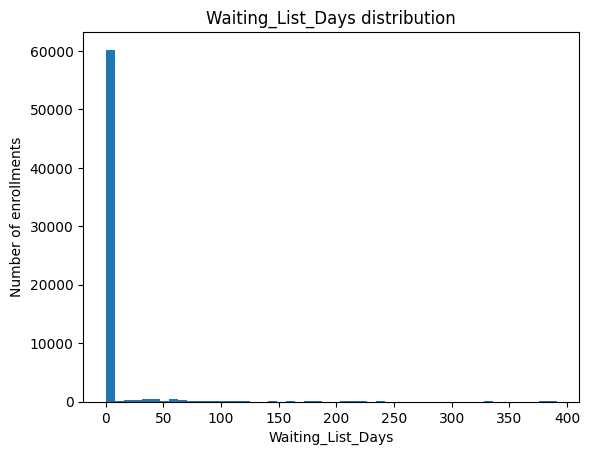

                   mean  count   pct
0 (no wait)    0.399674  60089  94.7
1+ (any wait)  0.676444   3375   5.3


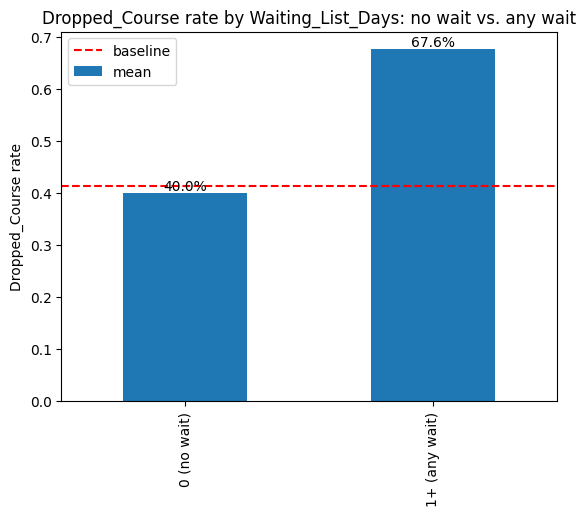


non-zero waiting days: {'mean': 74.90962962962963, '50%': 50.0}


In [50]:
col = "Waiting_List_Days"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=50)
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

dropped = df.loc[df[TARGET] == 1, col]
stayed = df.loc[df[TARGET] == 0, col]

on_waitlist = (df[col] > 0)
rate_by_waitlist = df.groupby(on_waitlist)[TARGET].agg(["mean", "count"])
rate_by_waitlist.index = ["0 (no wait)", "1+ (any wait)"]
rate_by_waitlist["pct"] = (rate_by_waitlist["count"] / len(df) * 100).round(1)
print(rate_by_waitlist)

ax = rate_by_waitlist["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_waitlist["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}: no wait vs. any wait")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

print("\nnon-zero waiting days:", df.loc[on_waitlist, col].describe()[["mean", "50%"]].to_dict())

**What can you infer about `Waiting_List_Days`?**

1. Above 94% of clients have `0` waiting days. This turns the question to a binary state - did a client wait or no? - zero vs non zero waiting days. 
2. Grouping by non-zero values creates a comperable group. Drop rate for zero wait clients is below 40% (mean), where any wait clients are at a much higher rate - above 67%, a 27% difference.while n=3375 sits at above 5% - not insignificant number. also, the mean of typical wait itself is almost 75 days - not a one day wait - fairly long.

**Decision:** keep `Waiting_List_Days` as a numeric predictor, and add a separate `has_waited` flag (`0` vs. `1+`) alongside it - same logic as `Daily_Tuition_Cost`'s `is_zero_cost`. The flag captures the clean 0-vs-nonzero jump (below 40% vs. above 67%) directly; the raw day count stays in too, since clients who did wait show real spread around a ~75-day mean, not a single value.

### Registration_Changes

count    63464.000000
mean         0.180039
std          0.592577
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: Registration_Changes, dtype: float64
missing: 0


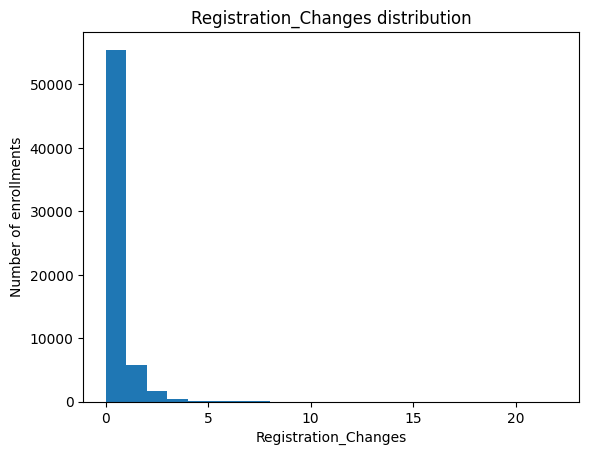

                          mean  count   pct
Registration_Changes                       
0                     0.450845  55478  87.4
1                     0.140554   5706   9.0
2                     0.216775   1693   2.7
3                     0.178674    347   0.5
4                     0.234043    141   0.2
5                     0.294118     34   0.1
6                     0.347826     23   0.0
7                     0.066667     15   0.0
8                     0.250000      8   0.0
9                     0.250000      4   0.0
10                    0.000000      1   0.0
11                    0.000000      1   0.0
12                    0.000000      1   0.0
13                    0.000000      3   0.0
14                    0.250000      4   0.0
15                    0.000000      2   0.0
17                    0.000000      1   0.0
20                    0.000000      1   0.0
21                    0.000000      1   0.0

bucketed 0 / 1 / 2+:
                          mean  count   pct
Registrati

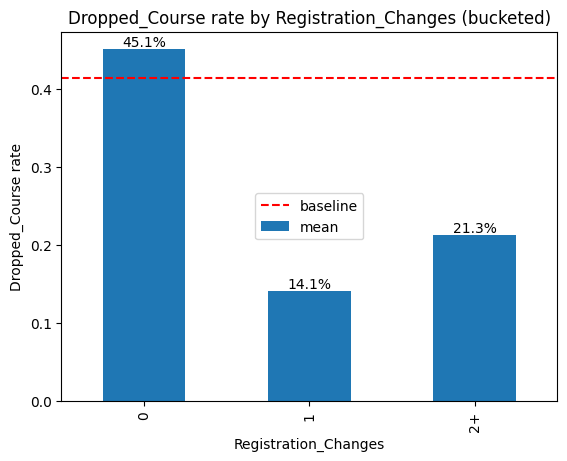

In [51]:
col = "Registration_Changes"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

bucket = pd.cut(df[col], bins=[-1, 0, 1, 100], labels=["0", "1", "2+"])
rate_by_bucket = df.groupby(bucket, observed=True)[TARGET].agg(["mean", "count"])
rate_by_bucket["pct"] = (rate_by_bucket["count"] / len(df) * 100).round(1)
print("\nbucketed 0 / 1 / 2+:")
print(rate_by_bucket)

ax = rate_by_bucket["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_bucket["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (bucketed)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Registration_Changes`?**
1. Still, we see a pattern where a mass of the data (above 87%) sits at `0`, with a right thin tail up to `21`. Value `1` alone has n=5,706 (9%) — large enough to stand on its own — while value `2` itself (2.7% of rows) counts fall off fast (`3`→347, `4`→141, `5`→34, ... down to n=1 by value `21`). Grouping everything `2+` together creates a more solid group (3.6%)

2. The bar chart shows us that `0` sits above baseline (45%), `1` drops well below at 14%, and the `2+` group shows a slight bump, and overall higher percentage - 21%, but still under baseline. Practically, this means a client that performs any changes to their registration is less likely to drop.

**Decision:** Group by `0`/`1`/`2+`. 

### Pre_Course_Supports_Tickets

count    63464.000000
mean         0.513330
std          0.763563
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: Pre_Course_Supports_Tickets, dtype: float64
missing: 0


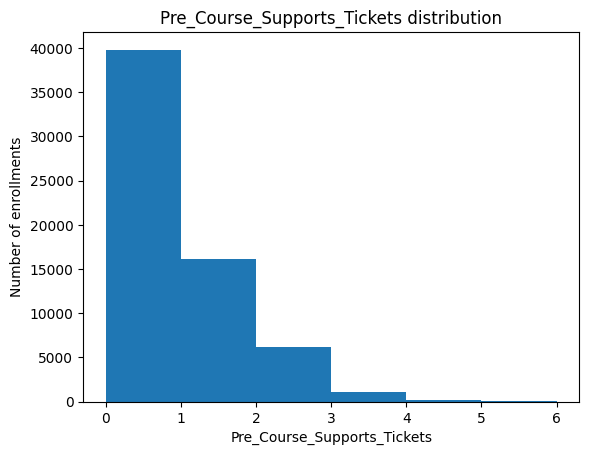

                                 mean  count   pct
Pre_Course_Supports_Tickets                       
0                            0.544364  39830  62.8
1                            0.195439  16138  25.4
2                            0.201191   6213   9.8
3                            0.174603   1134   1.8
4                            0.112782    133   0.2
5                            0.000000     16   0.0

bucketed 0 vs 1+:
                      mean  count   pct
0 (no tickets)    0.544364  39830  62.8
1+ (any tickets)  0.195354  23634  37.2


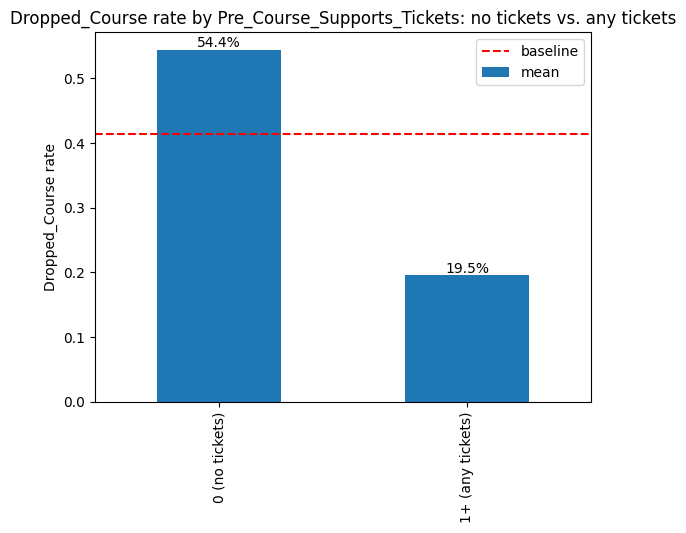

In [52]:
col = "Pre_Course_Supports_Tickets"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

had_ticket = (df[col] > 0)
rate_by_ticket = df.groupby(had_ticket)[TARGET].agg(["mean", "count"])
rate_by_ticket.index = ["0 (no tickets)", "1+ (any tickets)"]
rate_by_ticket["pct"] = (rate_by_ticket["count"] / len(df) * 100).round(1)
print("\nbucketed 0 vs 1+:")
print(rate_by_ticket)

ax = rate_by_ticket["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_ticket["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}: no tickets vs. any tickets")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Pre_Course_Supports_Tickets`?**

1. Most clients open 0 or 1 support ticket. 62.8% of clients have `0`, and the rest are spread across 1–5.
2. Drop rate by value: 0→54.4%, 1→19.5%, 2→20.1%, 3→17.5%, 4→11.3%, 5→0% (n=16, too small to trust on its own). `0` sits well above the baseline (41.4%). Every value from `1` upward drops sharply and stays low — unlike `Registration_Changes`, there's no bounce back up later, so `1`, `2`, `3`, and `4` are all telling the same story.
3. Because of that, we can safely group everything into two bars: `0` (54.4%) vs. `1+` (19.5%). Both groups are large, so this is a real, solid gap — not noise.

**Decision:** split `Pre_Course_Supports_Tickets` into `0` vs. `1+` (opened any support ticket before the course, or not).

### Professionals_Count

count    63464.000000
mean         1.835214
std          0.508607
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: Professionals_Count, dtype: float64
missing: 0


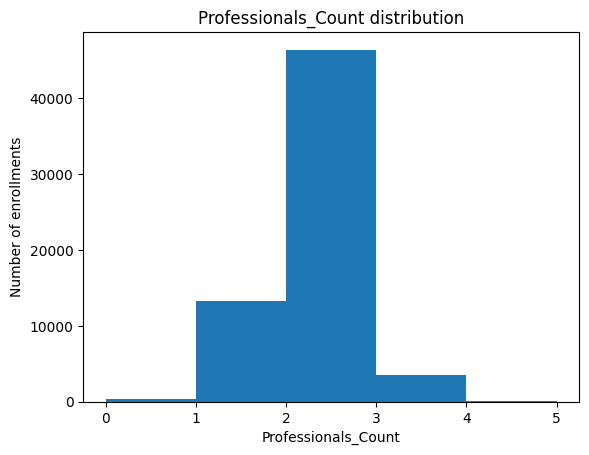

                         mean  count   pct
Professionals_Count                       
0                    0.263314    338   0.5
1                    0.337756  13264  20.9
2                    0.441973  46401  73.1
3                    0.353779   3440   5.4
4                    0.238095     21   0.0


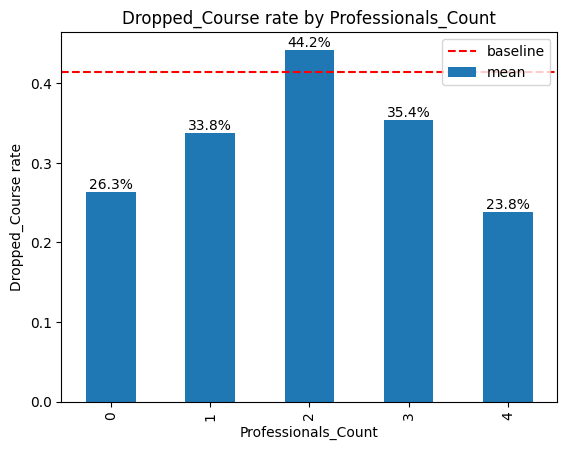

In [53]:
col = "Professionals_Count"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Professionals_Count`?**

1. `2` dominates (73.1%), with `1` (20.9%).`0`/`4` are thin tails.
2. Rate isn't monotonic - `0` (26.3%) and `4` (23.8%) sit well below baseline, `1` (33.8%)/`3` (35.4%) sit moderately below, and `2` (44.2%) is actually the highest-risk group, slightly above baseline.

**Decision:** keep as-is, 5 values, no cleaning needed. Don't collapse to `0` vs. `1+` - the non-monotonic shape (peak risk at `2`) is the signal itself.

### Students_Count

                    mean  count   pct
Students_Count                       
0.0             0.418426  59578  93.9
1.0             0.325178   2248   3.5
2.0             0.388745   1546   2.4
3.0             0.333333     33   0.1
9999.0          0.418182     55   0.1
NaN             1.000000      4   0.0

                          mean  count   pct
students_count_clean                       
0.0                   0.418426  59578  93.9
1.0                   0.325178   2248   3.5
2.0                   0.388745   1546   2.4
3.0                   0.333333     33   0.1


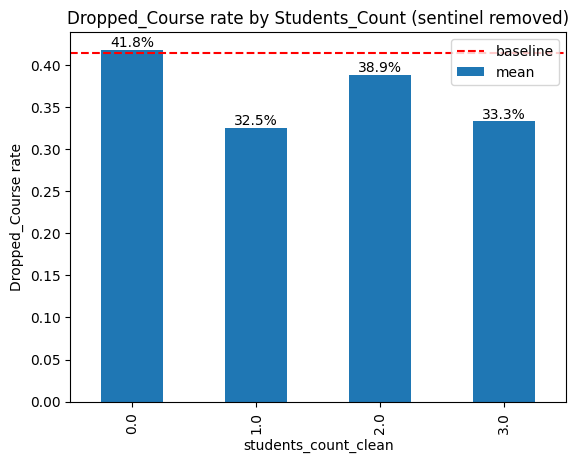

               mean  count   pct
has value  0.414352  63405  99.9
missing    0.457627     59   0.1


In [54]:
col = "Students_Count"

raw_rate = df.groupby(df[col], dropna=False)[TARGET].agg(["mean", "count"])
raw_rate["pct"] = (raw_rate["count"] / len(df) * 100).round(1)
print(raw_rate)

df["students_count_clean"] = df[col].where(df[col] != 9999)

print()
rate_by_val = df.groupby(df["students_count_clean"])[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (sentinel removed)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

rate_by_missing = df.groupby(df["students_count_clean"].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

**What can you infer about `Students_Count`?**

1. `0` holds the biggest count (93.9%). `9999` (n=55) must be some mistake - not a real headcount.
2. `9999` rows drop at 41.8% - same as baseline, and as `0`.
3. Cleaned rate: `0` (41.8%) at baseline, `1` (32.5%) and `2` (38.9%) below it - having any students registered is mildly protective. `3` (n=33) too small to trust.

**Decision:**
1. Treat `9999` as NaN (missing).
2. Fill all 59 missing values with the median, which is `0`.

### Observers_Count

count    63464.000000
mean         0.005326
std          0.089662
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: Observers_Count, dtype: float64
missing: 0
Observers_Count
0     63149
1       307
2         6
9         1
10        1
Name: count, dtype: int64
                        mean  count   pct
0 (no observers)    0.415620  63149  99.5
1+ (any observers)  0.168254    315   0.5


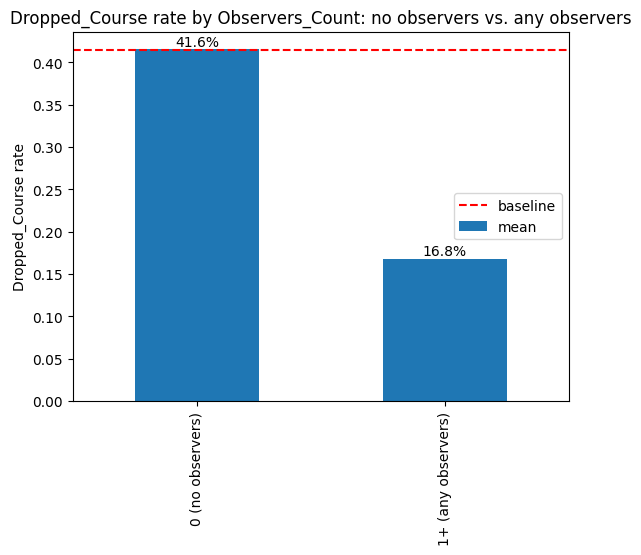

In [55]:
col = "Observers_Count"
print(df[col].describe())
print("missing:", df[col].isna().sum())
print(df[col].value_counts().sort_index())

has_observer = df[col] > 0
rate_by_observer = df.groupby(has_observer)[TARGET].agg(["mean", "count"])
rate_by_observer.index = ["0 (no observers)", "1+ (any observers)"]
rate_by_observer["pct"] = (rate_by_observer["count"] / len(df) * 100).round(1)
print(rate_by_observer)

ax = rate_by_observer["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_observer["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}: no observers vs. any observers")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Observers_Count`?**

1. 99.5% of orders have `0` observers (63,149). Remaining 315 rows are almost all `1` (307), with a handful at `2`/`9`/`10`.
2. Orders with any observers drop at 16.8% vs. 41.6% for none - a large gap, even if n is small for non zero values.

**Decision:** treat as `0` vs. `1+` binary categories.

### Practical_Hours

Practical_Hours
-5           30
-1           35
 0        30671
 1        17002
 2        15074
 3          246
 4          230
 5           43
 6           39
 7            6
 8           24
 9            6
 10           2
 13           1
 14           2
 16           1
 5000        30
 10000       22
Name: count, dtype: int64

sentinel rows: 117
                     mean  count
Practical_Hours                 
False            0.414290  63347
True             0.470085    117


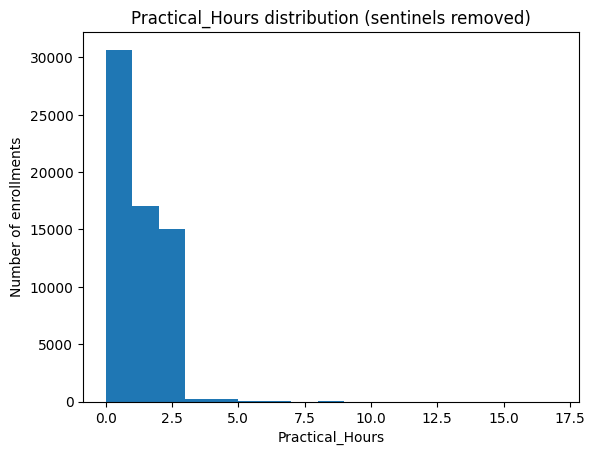

                           mean  count   pct
practical_hours_clean                       
0.0                    0.429591  30671  48.3
1.0                    0.394483  17002  26.8
2.0                    0.399031  15074  23.8
3.0                    0.443089    246   0.4
4.0                    0.634783    230   0.4
5.0                    0.604651     43   0.1
6.0                    0.794872     39   0.1
7.0                    1.000000      6   0.0
8.0                    0.916667     24   0.0
9.0                    0.666667      6   0.0
10.0                   1.000000      2   0.0
13.0                   0.000000      1   0.0
14.0                   0.000000      2   0.0
16.0                   0.000000      1   0.0
               mean  count   pct
has value  0.414290  63347  99.8
missing    0.470085    117   0.2


In [56]:
col = "Practical_Hours"
print(df[col].value_counts().sort_index())

sentinels = [-5, -1, 5000, 10000]
print("\nsentinel rows:", df[col].isin(sentinels).sum())
print(df.groupby(df[col].isin(sentinels))[TARGET].agg(["mean", "count"]))

df["practical_hours_clean"] = df[col].where(~df[col].isin(sentinels))

plt.hist(df["practical_hours_clean"].dropna(), bins=range(0, 18))
plt.title(f"{col} distribution (sentinels removed)")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(df["practical_hours_clean"])[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

rate_by_missing = df.groupby(df["practical_hours_clean"].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

**What can you infer about `Practical_Hours`?**

1. Real values cluster in 0-16 hours (`0` n=30,671, `1` n=17,002, `2` n=15,074, thin tail to `16`). `-5`/`-1`/`5000`/`10000` (117 rows total) aren't plausible planned hours - sentinels, not data.
2. Sentinel rows have a 47.0% drop rate vs. 41.4% - a bit elevated, but n=117 (0.2%) is too small to trust as real.
3. Cleaned distribution is right-skewed, centered 0-2 hours with a thin tail to `16`.
4. Missingness after recoding is 0.2% - too small a slice to check meaningfully.

**Decision:** use `practical_hours_clean` (sentinels recoded to NaN). Given the small share affected, a median fill in Stage 3 is fine - no need for a separate missing indicator.

### Theory_Hours

count    63464.000000
mean         2.164392
std          1.469854
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         41.000000
Name: Theory_Hours, dtype: float64
missing: 0
                  mean  count   pct
Theory_Hours                       
0             0.309271   4045   6.4
1             0.368493  16885  26.6
2             0.482555  21668  34.1
3             0.399093  12784  20.1
4             0.383993   4823   7.6
5             0.389351   2404   3.8
6             0.489510    286   0.5
7             0.496644    149   0.2
8             0.481818    110   0.2
9             0.583333     60   0.1
10            0.626087    115   0.2
11            0.750000     24   0.0
12            0.823529     17   0.0
13            0.600000     10   0.0
14            0.916667     12   0.0
15            0.888889     18   0.0
16            0.666667      9   0.0
17            0.666667      3   0.0
18            0.833333      6   0.0
19            0.800000

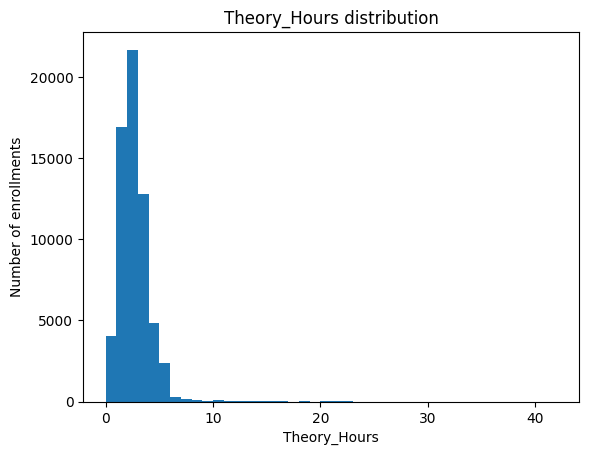

/var/folders/dr/27_gtzy14b3cd8jgjvglzyv00000gn/T/ipykernel_31999/3634491923.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])


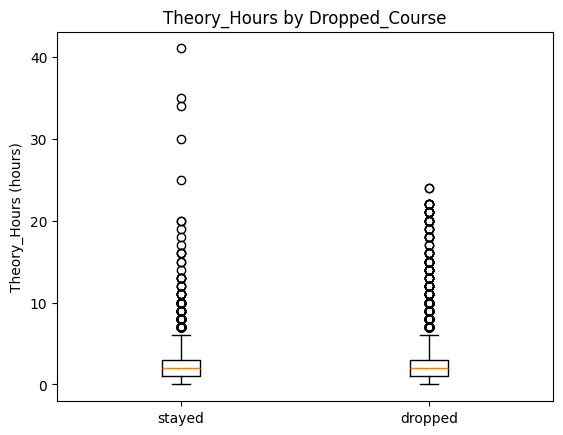

stayed: {'mean': 2.1088120543522133, '50%': 2.0}
dropped: {'mean': 2.242936993802046, '50%': 2.0}


In [57]:
col = "Theory_Hours"
print(df[col].describe())
print("missing:", df[col].isna().sum())

rate_by_val = df.groupby(df[col])[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

dropped = df.loc[df[TARGET] == 1, col]
stayed = df.loc[df[TARGET] == 0, col]

plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])
plt.title(f"{col} by {TARGET}")
plt.ylabel(f"{col} (hours)")
plt.show()

print("stayed:", stayed.describe()[["mean", "50%"]].to_dict())
print("dropped:", dropped.describe()[["mean", "50%"]].to_dict())

**What can you infer about `Theory_Hours`?**

1. Right-skewed count centered 1-3 hours (median 2, mean 2.16), tail out to 41 - no negative values or sentinel jump like `Practical_Hours` had, so this looks like genuine variation.
2. Stayed vs. dropped distributions are nearly identical - mean 2.11/median 2.0 vs. mean 2.24/median 2.0 - essentially no separation.

**Decision:** keep as a numeric predictor for completeness, but expect little signal - the two groups barely differ. Flag the 41-hour max for a second look in Stage 2, same treatment as `Registration_Days_Before`'s tail.

### Daily_Tuition_Cost

count    63385.000000
mean        98.847963
std         41.855391
min          0.000000
25%         75.000000
50%         94.500000
75%        117.000000
max       5400.000000
Name: Daily_Tuition_Cost, dtype: float64
missing: 79
3 most extreme (highest) values:
                    mean  count  pct
Daily_Tuition_Cost                  
5400.0               1.0      1  0.0
451.5                0.0      1  0.0
375.5                0.0      1  0.0


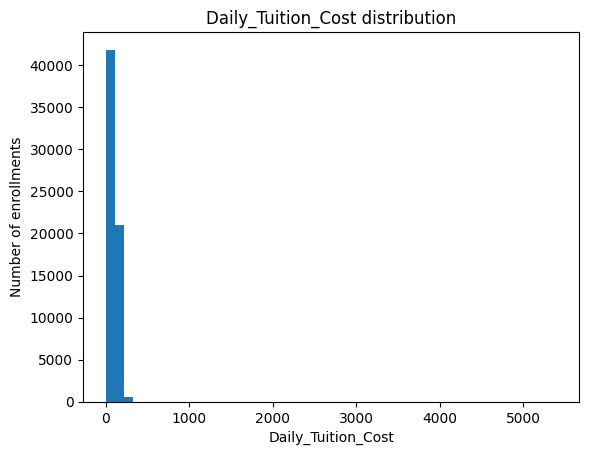

/var/folders/dr/27_gtzy14b3cd8jgjvglzyv00000gn/T/ipykernel_31999/3505150289.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])


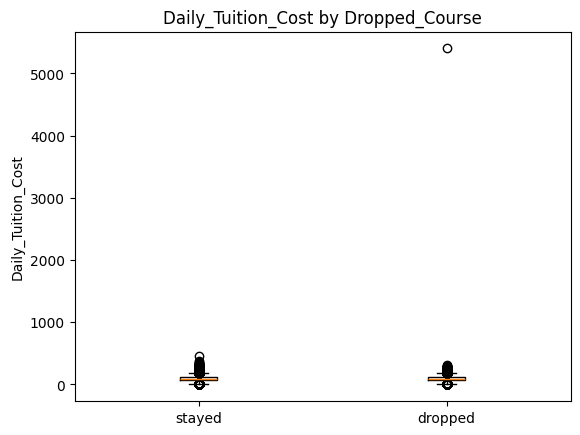

stayed: {'mean': 99.69861771756402, '50%': 95.0}
dropped: {'mean': 97.64519651153934, '50%': 93.0}
                  mean  count   pct
nonzero cost  0.419748  62385  98.3
zero cost     0.104727   1079   1.7


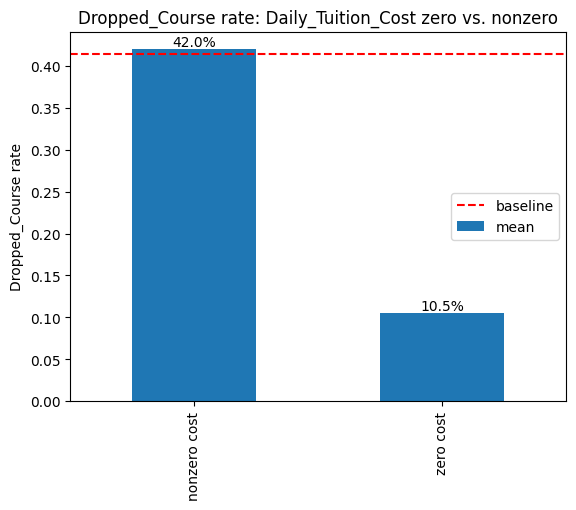

               mean  count   pct
has value  0.414262  63385  99.9
missing    0.518987     79   0.1


In [58]:
col = "Daily_Tuition_Cost"
print(df[col].describe())
print("missing:", df[col].isna().sum())

rate_by_val = df.groupby(df[col])[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print("3 most extreme (highest) values:")
print(rate_by_val.sort_index(ascending=False).head(3))

plt.hist(df[col].dropna(), bins=50)
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

dropped = df.loc[df[TARGET] == 1, col].dropna()
stayed = df.loc[df[TARGET] == 0, col].dropna()

plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])
plt.title(f"{col} by {TARGET}")
plt.ylabel(f"{col}")
plt.show()

print("stayed:", stayed.describe()[["mean", "50%"]].to_dict())
print("dropped:", dropped.describe()[["mean", "50%"]].to_dict())

is_zero = df[col] == 0
rate_by_zero = df.groupby(is_zero)[TARGET].agg(["mean", "count"])
rate_by_zero.index = ["nonzero cost", "zero cost"]
rate_by_zero["pct"] = (rate_by_zero["count"] / len(df) * 100).round(1)
print(rate_by_zero)

ax = rate_by_zero["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_zero["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate: {col} zero vs. nonzero")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

**What can you infer about `Daily_Tuition_Cost`?**

1. Right-skewed: median 94.5, mean 98.8, 75th percentile only 117 - extreme values pull the mean above the median.
2. Stayed vs. dropped are almost identical in mean and median - no meaningful difference.
3. `0` shows a 10.5% drop rate vs. 42.0% for everything else - a huge gap. Practically, clients that didn't pay have a much lower tendency to drop.
4. 79 rows (0.1%) are missing, with a 51.9% drop rate - size is too small to trust as real behavior.
5. `5400` seems like outlier - seen in fig 2.

**Decision:**
1. Keep as a numeric predictor, using median over mean given the skew.
2. Remove 5400 value.
3. Add a new is_zero_cost column (1 if cost is exactly 0, else 0) — So the model is told directly which rows are the zero/nonzero bookings, and perhaps improve its accuracy.
4. 79 missing rows - median fill for now, perhaps revisit.


### Physical_Course_Kits

Physical_Course_Kits
0.0    60790
1.0     1632
2.0        1
3.0        1
NaN     1040
Name: count, dtype: int64
missing: 1040 (1.64%)
                          mean  count   pct
Physical_Course_Kits                       
0.0                   0.425892  60790  95.8
1.0                   0.000000   1632   2.6
2.0                   0.000000      1   0.0
3.0                   0.000000      1   0.0


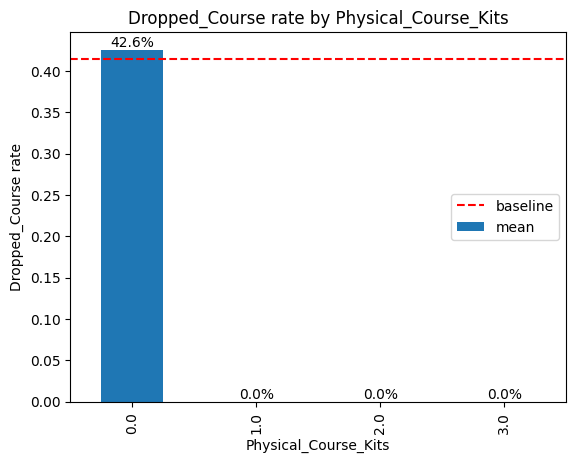

               mean  count   pct
has value  0.414744  62424  98.4
missing    0.393269   1040   1.6


In [59]:
col = "Physical_Course_Kits"
print(df[col].value_counts(dropna=False).sort_index())
print("missing:", df[col].isna().sum(), f"({df[col].isna().mean():.2%})")

rate_by_val = df.groupby(df[col])[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

**What can you infer about `Physical_Course_Kits`?**

1. Almost entirely `0` (95.8%), with `1` (2.6%) as the only substantial nonzero value; `2`/`3` are single rows each. 1,040 rows (1.6%) are missing.
2. `0` sits at 42.6% (close to baseline). `1` shows an exact 0.0% drop rate across all 1,632 rows - deterministic.
3. It seems like the value is set *after* the outcome is already known. Likely mechanism: a kit is only prepared/shipped once a client is confirmed to attend, so `1` may just be relabeling "attended" rather than predicting it.
3. Overall, the scenario look reasonable - if you are not doing the course - you probably wont get a physical kit. It seems like this variable is not beneficial. 

**Decision:** 
1. Drop this variable.


## Categorical variables

Clean, already low-cardinality categoricals — no dirty-text cleanup needed before use.

### Returning_Client

                  count   pct
Returning_Client             
0                 61742  97.3
1                  1722   2.7
                      mean  count   pct
Returning_Client                       
0                 0.419261  61742  97.3
1                 0.239837   1722   2.7


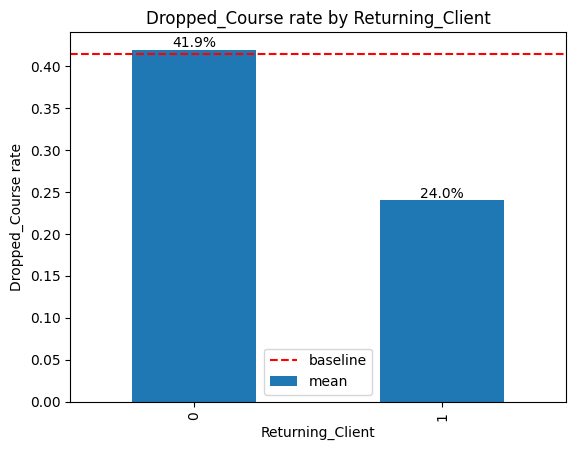

Returning_Client: chi2=221.50, p=4.251e-50


In [60]:
col = "Returning_Client"
vc = df[col].value_counts().to_frame()
vc["pct"] = (vc["count"] / len(df) * 100).round(1)
print(vc)

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

table = pd.crosstab(df[col], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"{col}: chi2={chi2:.2f}, p={p:.3e}")

**What can you infer about `Returning_Client`?**

1. returning clients (`1`) drop out much less than new ones (`0`) — 24.0% vs. 41.9%. New clients are at almost identical to baseline, so we can infer a returning client is less likely to drop.

**Decision:** keep as is.

### Welcome_Gift_Type

unique: 4
missing: 0
                       mean  count   pct
Welcome_Gift_Type                       
Branded Notebook   0.411068  32238  50.8
Water Bottle       0.416734  18429  29.0
USB Drive          0.419657  10144  16.0
Portable Charger   0.418394   2653   4.2


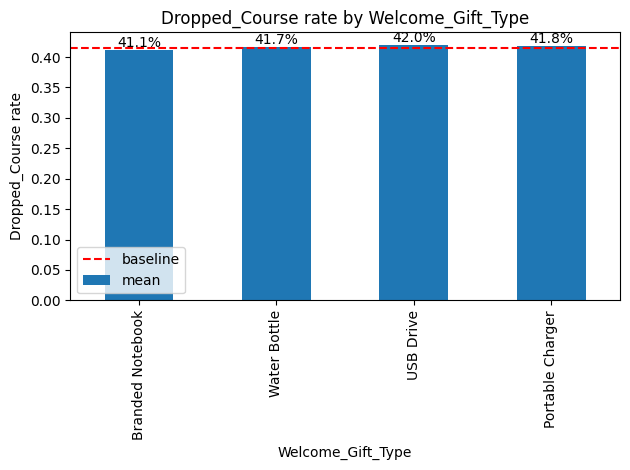

In [61]:
col = "Welcome_Gift_Type"
print("unique:", df[col].nunique())
print("missing:", df[col].isna().sum())

rate_by_cat = df.groupby(col)[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

**What can you infer about `Welcome_Gift_Type`?**

1. The bar chart shows all 4 gifts sitting very close to baseline —  seems like a meaningless variable.

**Decision:** drop `Welcome_Gift_Type` from the feature set.

### Requested_Lab_Config

unique: 8
missing: 1736 (2.74%)
                            mean  count   pct
Requested_Lab_Config                         
Standard PC (Windows)   0.432948  49708  78.3
Linux Workstation       0.341955   8390  13.2
Dual Monitor Setup      0.387879   1320   2.1
MacOS Station           0.289738    994   1.6
Laptop Docking Station  0.325820    976   1.5
High-GPU Unit           0.211838    321   0.5
Touch Screen Interface  0.416667     12   0.0
VR/AR Station           1.000000      7   0.0


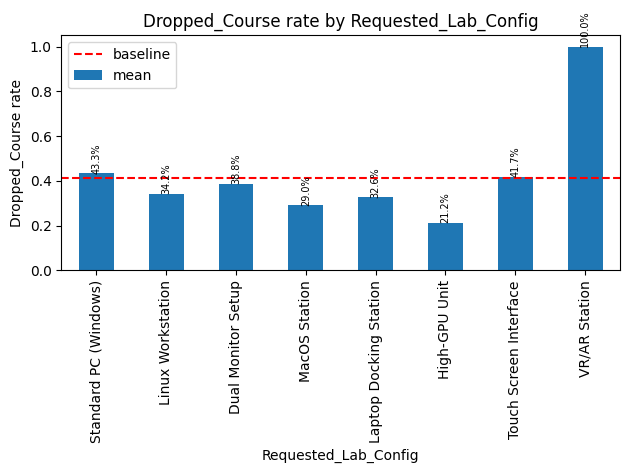

               mean  count   pct
has value  0.414528  61728  97.3
missing    0.409562   1736   2.7


In [62]:
col = "Requested_Lab_Config"
print("unique:", df[col].nunique())
print("missing:", df[col].isna().sum(), f"({df[col].isna().mean():.2%})")

rate_by_cat = df.groupby(col)[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]], fontsize=7, rotation=90)
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

**What can you infer about `Requested_Lab_Config`?**

1. 2.7% of rows (n=1,736) are missing.
2. `Touch Screen Interface` (n=12) and `VR/AR Station` (n=7) are both too small to read — `VR/AR Station`'s 100% rate in particular is just n=7, not a real effect.
3. Missingness (2.7%, n=1,736) isn't checked against target here since the column will be compared directly against `Assigned_Lab_Config` next.

**Decision:** one-hot encode the 6 substantial categories, fold `Touch Screen Interface` and `VR/AR Station` into `OTHER` given tiny n, and keep `MISSING` as its own category. Hold off on any request-vs-assigned mismatch feature until Stage 2 — that's a derived feature, not a Stage 1 observation.

### Assigned_Lab_Config

unique: 9
missing: 0
                            mean  count   pct
Assigned_Lab_Config                          
Standard PC (Windows)   0.475090  45926  72.4
Linux Workstation       0.263352  11665  18.4
Laptop Docking Station  0.230270   1850   2.9
MacOS Station           0.204903   1591   2.5
Dual Monitor Setup      0.349614   1556   2.5
High-GPU Unit           0.153398    515   0.8
Server Access Terminal  0.049587    242   0.4
Touch Screen Interface  0.117117    111   0.2
VR/AR Station           1.000000      8   0.0


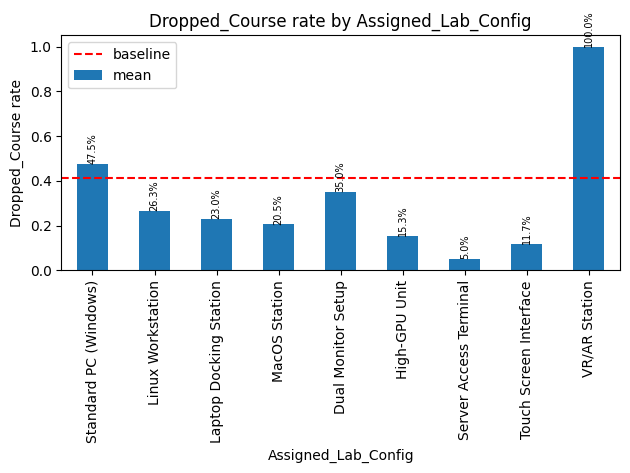

                           mean  count   pct
assigned == requested  0.454151  57133  90.0
assigned != requested  0.055599   6331  10.0


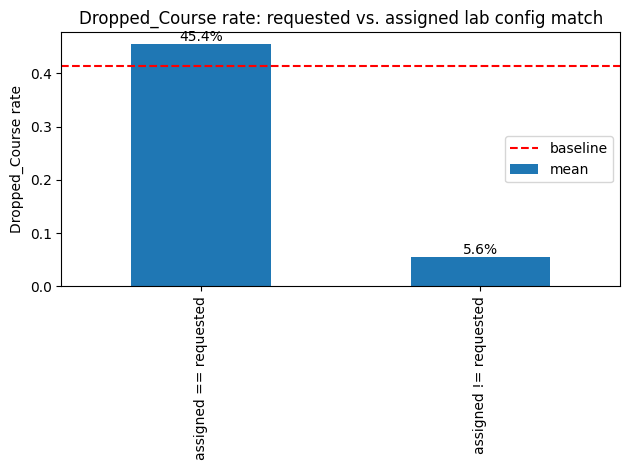

In [63]:
col = "Assigned_Lab_Config"
print("unique:", df[col].nunique())
print("missing:", df[col].isna().sum())

rate_by_cat = df.groupby(col)[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]], fontsize=7, rotation=90)
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

mismatch = df["Requested_Lab_Config"].notna() & (df["Requested_Lab_Config"] != df[col])
rate_by_match = df.groupby(mismatch)[TARGET].agg(["mean", "count"])
rate_by_match.index = ["assigned == requested", "assigned != requested"]
rate_by_match["pct"] = (rate_by_match["count"] / len(df) * 100).round(1)
print(rate_by_match)

ax = rate_by_match["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_match["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate: requested vs. assigned lab config match")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

**What can you infer about `Assigned_Lab_Config`?**

1. 9 categories, no missing values (one more than `Requested_Lab_Config`: `Server Access Terminal` only appears here, never as a request).
2. The requested vs assigned plot shows as if a client that didn't get what he requesed - he was less likely to drop. Seems unreasonable. 

**Decision:** a mismatch can only happen for clients who attended (you can only reassign someone who shows up), so it reflects attendance
rather than predicting it. We'll drop this variable.


## Datetime variables

### Course_Start_Date

count                            63464
mean     2016-06-23 05:17:23.287533056
min                2015-07-01 00:00:00
25%                2016-02-13 00:00:00
50%                2016-07-01 00:00:00
75%                2016-11-11 00:00:00
max                2017-04-26 00:00:00
Name: Course_Start_Date, dtype: object
                       mean  count  pct
Course_Start_Date                      
2015-07-01         0.671674   1398  2.2
2015-08-01         0.496774   2480  3.9
2015-09-01         0.437234   3529  5.6
2015-10-01         0.390136   3386  5.3
2015-11-01         0.243725   1235  1.9
2015-12-01         0.403869   1654  2.6
2016-01-01         0.321114   1364  2.1
2016-02-01         0.392240   2371  3.7
2016-03-01         0.363756   3046  4.8
2016-04-01         0.432182   3561  5.6
2016-05-01         0.390642   3676  5.8
2016-06-01         0.438440   3923  6.2
2016-07-01         0.333120   3131  4.9
2016-08-01         0.369153   3378  5.3
2016-09-01         0.404805   3871  6.1
2016-10-

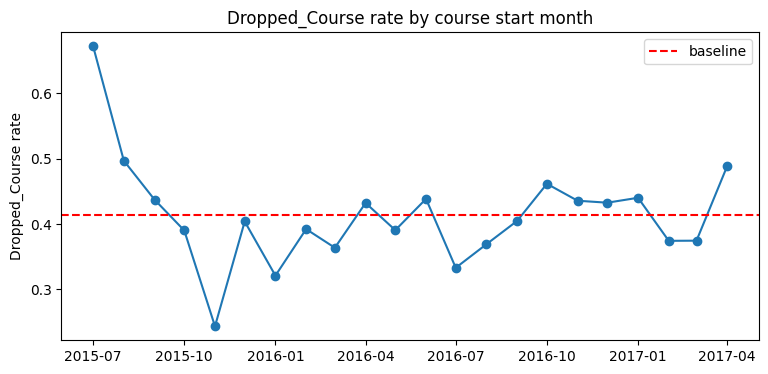

In [64]:
col = "Course_Start_Date"
df[col] = pd.to_datetime(df[col])
print(df[col].describe())

monthly = df.set_index(col).resample("MS")[TARGET].agg(["mean", "count"])
monthly["pct"] = (monthly["count"] / len(df) * 100).round(1)
print(monthly)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly["mean"], marker="o")
ax.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
ax.set_ylabel(f"{TARGET} rate")
ax.set_title(f"{TARGET} rate by course start month")
ax.legend()
plt.show()

**What can you infer about `Course_Start_Date`?**
1. It's a datetime variable. We will need to convert it to a numeric value.
2. High drop rate at `07/2015`, low at `11/2015`, otherwise steady around baseline. These two extreme months are also among the smallest sample sizes (n=1,398 and n=1,235, vs. `01/2016`'s n=1,364 as another small month), so the extreme rates are more sensitive to sampling noise, not just a stronger effect. For now we will not define them as outliers, possible change later on.

**Decision:** 
1. Converting datetime to numerical - days from start.
2. Possible outliers (`11/2015`, `07/2015`). We wont define them as such for now.

## Text variables

### Origin_Country

raw unique: 721 -> cleaned unique: 154
               count   pct
country_clean             
PRT            26429  41.6
FRA             6961  11.0
DEU             4400   6.9
ESP             3896   6.1
GBR             3514   5.5
ITA             2726   4.3
BRA             1402   2.2
BEL             1324   2.1
NLD             1222   1.9
USA             1072   1.7
CHN             1054   1.7
CHE              935   1.5
IRL              808   1.3
AUT              782   1.2
MISSING          557   0.9
ISR              542   0.9
SWE              512   0.8
POL              462   0.7
RUS              348   0.5
AGO              309   0.5


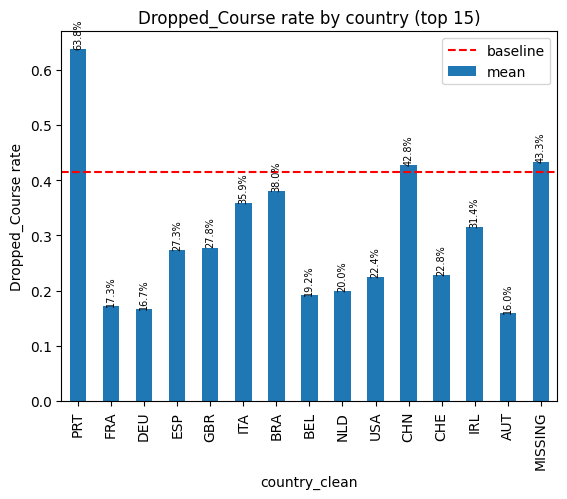

Origin_Country: chi2=10869.46, dof=153, p=0.000e+00


In [65]:
col = "Origin_Country"
raw = df[col].astype(str)
cleaned = raw.str.upper().str.replace(r"[^A-Z]", "", regex=True)
cleaned = cleaned.replace("CN", "CHN")
cleaned = cleaned.where(df[col].notna(), "MISSING")
df["country_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["country_clean"].nunique())

vc = df["country_clean"].value_counts().to_frame()
vc["pct"] = (vc["count"] / len(df) * 100).round(1)
print(vc.head(20))

top = vc.head(15).index
rate_by_country = df[df["country_clean"].isin(top)].groupby("country_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_country["pct"] = (rate_by_country["count"] / len(df) * 100).round(1)

ax = rate_by_country["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_country["mean"]], fontsize=7, rotation=90)
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by country (top 15)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

table = pd.crosstab(df["country_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"{col}: chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

**What can you infer about `Origin_Country`?**

1. 721 raw values - only 154 actual countries.
2. 557 rows (0.9%) have no country. Their drop rate (43.3%) is almost identical to the baseline (41.4%), so missingness itself carries no signal here.
3. `PRT` is the largest group by far (41.6% of all rows) and also the highest-risk one, at a 64% drop rate against a 41.4% baseline. Every other major country is more reasonable — at or below baseline (e.g. `FRA` 17%, `DEU` 17%, `GBR` 28%). Practically, this means `PRT` alone could end up dominating the model's use of this feature if we're not careful about how it's encoded. p-value (around 0) approves this is no coincidence.


**Decision:** we want to avoid one-hot encoding to all unique values and create 154 more columns. Instead we'll keep the large groups (% >= 4.0) as their own one-hot columns (`PRT`, `FRA`, `DEU`, `ESP`, `GBR`, `ITA`), and have `OTHER` column, and `MISSING`. That gets us to 8 columns, hoping we won't need to revisit this.

### Client_Category

raw unique: 505 -> cleaned unique: 8
                         count   pct
client_category_clean               
SAAS SOFTWARE HOUSES     29257  46.1
TRADITIONAL IT TELECOMM  14392  22.7
BIG TECH MULTINATIONALS  11909  18.8
FINTECH BANKING           4672   7.4
INDUSTRIAL TECH IOT       2603   4.1
NONPROFIT EDUTECH          465   0.7
DEFENSE GOVTECH            164   0.3
UNKNOWN                      2   0.0
                             mean  count   pct
client_category_clean                         
SAAS SOFTWARE HOUSES     0.360119  29257  46.1
TRADITIONAL IT TELECOMM  0.428016  14392  22.7
BIG TECH MULTINATIONALS  0.683685  11909  18.8
FINTECH BANKING          0.172517   4672   7.4
INDUSTRIAL TECH IOT      0.216289   2603   4.1
NONPROFIT EDUTECH        0.116129    465   0.7
DEFENSE GOVTECH          0.219512    164   0.3
UNKNOWN                  1.000000      2   0.0


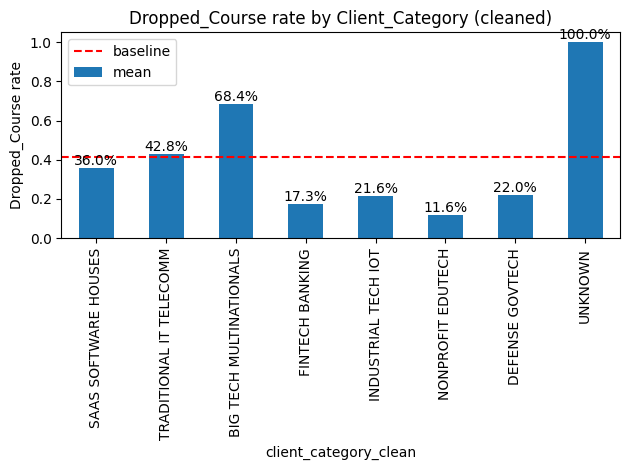

Client_Category: chi2=5671.19, dof=7, p=0.000e+00


In [66]:
col = "Client_Category"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
df["client_category_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["client_category_clean"].nunique())

vc = df["client_category_clean"].value_counts().to_frame()
vc["pct"] = (vc["count"] / len(df) * 100).round(1)
print(vc)

rate_by_cat = df.groupby("client_category_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["client_category_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"{col}: chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

**What can you infer about `Client_Category`?**
1. 505 raw values - actual 8 unique categories.
2. `SAAS SOFTWARE HOUSES` is the largest category by far (46.1% of rows, n=29,257) and sits somewhat below baseline at 36.0%. `TRADITIONAL IT TELECOMM` (22.7%) sits close to baseline at 42.8%. `BIG TECH MULTINATIONALS` is the outlier — only the third-largest group (18.8%) but far above baseline in risk, at 68.4% (27 points above). The remaining groups (`FINTECH BANKING` 7.4%, `INDUSTRIAL TECH IOT` 4.1%, `NONPROFIT EDUTECH` 0.7%, `DEFENSE GOVTECH` 0.3%) are all well below baseline (17%-22%) but each is a small share of rows. p-value (around 0) confirms this pattern isn't coincidence.
3. `UNKNOWN` is not relevant (n=2).

**Decision:** 
1. Drop `UNKNOWN` - outlier.
2. Convert 505 raw vals to 7 unique values, using one-hot encoder.

### Payment_Terms

raw unique: 236 -> cleaned unique: 5
                           mean  count   pct
payment_terms_clean                         
PAY UPON START         0.294390  51751  81.5
PREPAID NONREFUNDABLE  0.997757  10698  16.9
MISSING                0.367424    792   1.2
UNKNOWN                0.443925    214   0.3
REFUNDABLE DEPOSIT     0.444444      9   0.0


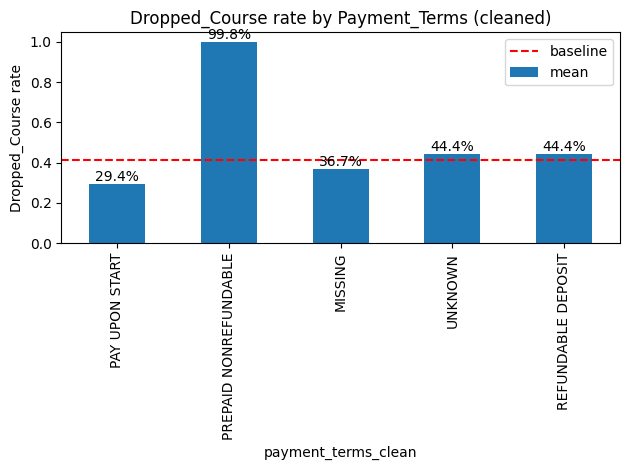

Payment_Terms: chi2=18081.48, dof=4, p=0.000e+00
                           mean  count   pct
payment_terms_bucket                        
PAY UPON START         0.294390  51751  81.5
PREPAID NONREFUNDABLE  0.997757  10698  16.9
OTHER                  0.384236   1015   1.6


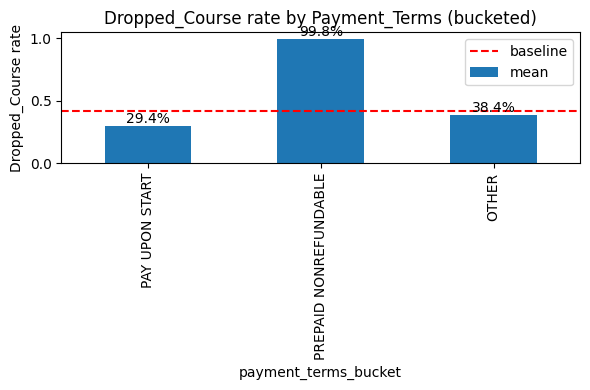

In [67]:
col = "Payment_Terms"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["payment_terms_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["payment_terms_clean"].nunique())

rate_by_cat = df.groupby("payment_terms_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["payment_terms_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"{col}: chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

bins = ["PAY UPON START", "PREPAID NONREFUNDABLE"]
df["payment_terms_bucket"] = df["payment_terms_clean"].where(df["payment_terms_clean"].isin(bins), "OTHER")

rate_by_bucket = df.groupby("payment_terms_bucket")[TARGET].agg(["mean", "count"])
rate_by_bucket["pct"] = (rate_by_bucket["count"] / len(df) * 100).round(1)
order = ["PAY UPON START", "PREPAID NONREFUNDABLE", "OTHER"]
rate_by_bucket = rate_by_bucket.reindex(order).fillna(0)
print(rate_by_bucket)

fig, ax = plt.subplots(figsize=(6, 4))
ax = rate_by_bucket["mean"].plot(kind="bar", ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_bucket["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (bucketed)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

**What can you infer about `Payment_Terms`?**

1. We see 2 dominating groups in size - `PAY UPON START` (81%) and `PREPAID NONREFUNDABLE` (17%). The remaining three together make up under 2% of rows.
2. `PAY UPON START` sits well below baseline at 29.4%, while `PREPAID NONREFUNDABLE` is almost at absolute 100%. Practically, almost every client that was on the `PREPAID NONREFUNDABLE` method - dropped. This is very unusual. We will look for another column that might explain this behavior - perhaps a variable that relates to how clients registrated or came in.


In [68]:
is_prepaid = df["payment_terms_clean"] == "PREPAID NONREFUNDABLE"

et_clean = df["Enrollment_Type"].astype(str).str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
et_clean = et_clean.str.replace(r"\s+", " ", regex=True).str.strip()
is_affiliated = et_clean == "AFFILIATED ADMISSION"

split = df[is_prepaid].groupby(is_affiliated)[TARGET].agg(["mean", "count"])
split.index = ["not affiliated", "affiliated"]
split["pct"] = (split["count"] / is_prepaid.sum() * 100).round(1)
print(split)

exceptions_mask = is_prepaid & (df[TARGET] == 0)
print("\nexceptions (prepaid, did not drop):", exceptions_mask.sum())
print(et_clean[exceptions_mask].value_counts())

                    mean  count   pct
not affiliated  1.000000   9695  90.6
affiliated      0.976072   1003   9.4

exceptions (prepaid, did not drop): 24
Enrollment_Type
AFFILIATED ADMISSION    24
Name: count, dtype: int64


3. We decided to check `Enrollment_Type`, and split `PREPAID NONREFUNDABLE` into two groups by it — `Affiliated Admission` vs. not affiliated (a manual grouping we made) — and saw an interesting connection: rows that are `PREPAID NONREFUNDABLE` AND not affiliated have a 100% drop rate (n=9,695). Moreover, all 24 samples that did not drop turned out to be `Affiliated Admission`.

**Decision:**
1. We'll split `Payment_Terms` into 3 groups — `PAY UPON START` / `PREPAID NONREFUNDABLE` / `OTHER`.
2. `PREPAID NONREFUNDABLE` + non-affiliated (the 100% drop slice, n=9,695) — we suspect this slice is too deterministic to trust, so we're excluding it from the model for now. We'll revisit if we can confirm whether `Payment_Terms` is known at enrollment or set later.
3. `PREPAID NONREFUNDABLE` + `Affiliated Admission` (n=1,003, 97.6%) doesn't show the same all-or-nothing pattern, so we're keeping that part as an ordinary signal within the `PREPAID NONREFUNDABLE` bucket.

### Enrollment_Type

raw unique: 298 -> cleaned unique: 5
                            count   pct
enrollment_type_clean                  
GENERAL ADMISSION           45199  71.2
AFFILIATED ADMISSION        15034  23.7
CONTRACTUAL AGREEMENT        2272   3.6
MISSING                       719   1.1
ORGANIZATIONAL ARRANGEMENT    240   0.4


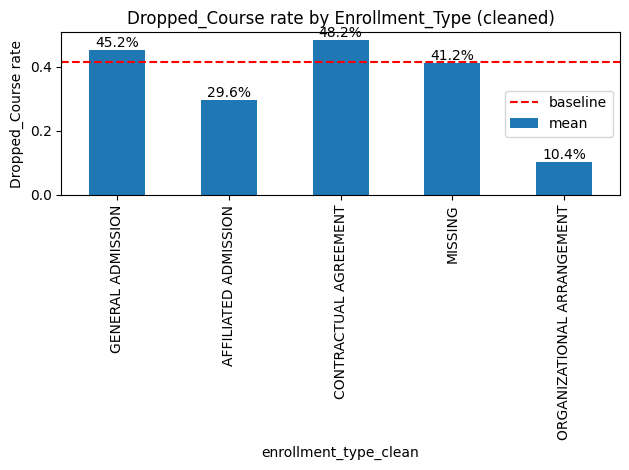

Enrollment_Type: chi2=1265.85, dof=4, p=8.426e-273
               mean  count   pct
has value  0.414423  62745  98.9
missing    0.411683    719   1.1


In [69]:
col = "Enrollment_Type"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["enrollment_type_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["enrollment_type_clean"].nunique())

vc = df["enrollment_type_clean"].value_counts().to_frame()
vc["pct"] = (vc["count"] / len(df) * 100).round(1)
print(vc)

rate_by_cat = df.groupby("enrollment_type_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["enrollment_type_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"{col}: chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

**What can you infer about `Enrollment_Type`?**

1. 298 raw values - actual 5 distinct categories.
2. 2 major categories - `GENERAL ADMISSION` (71.2%), `AFFILIATED ADMISSION` (23.7%) together compile 95% of rows. Remaining three differ in drop rate.
3. We have 1% of rows with missing values, but drop rate is very close to baseline.

**Decision:** one hot encode all 5 categories. perhaps revisit and change to 3 categories - GENERAL, AFFILIATED, OTHER.

### Submission_Source

raw unique: 328 -> cleaned unique: 6
                               count   pct
submission_source_clean                   
B2B PLATFORMS RESELLERS        54286  85.5
DIRECT WEBSITE REGISTRATION     5164   8.1
DEDICATED SALES TEAM            2853   4.5
MISSING                          790   1.2
UNKNOWN                          224   0.4
GOVERNMENT PROCUREMENT SYSTEM    147   0.2


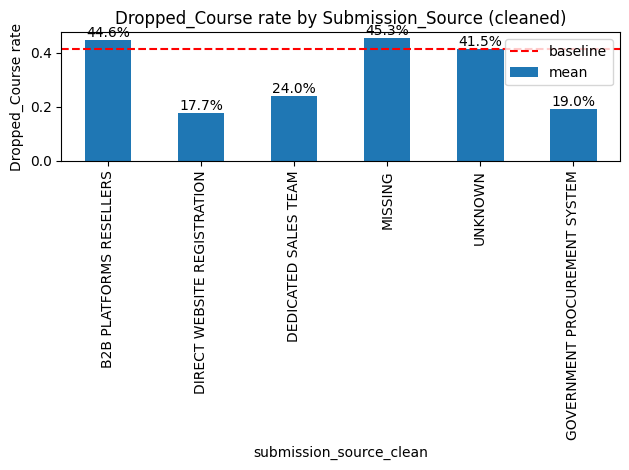

Submission_Source: chi2=1811.52, dof=5, p=0.000e+00
               mean  count   pct
has value  0.414006  62859  99.0
missing    0.454545    605   1.0


In [70]:
col = "Submission_Source"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["submission_source_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["submission_source_clean"].nunique())

vc = df["submission_source_clean"].value_counts().to_frame()
vc["pct"] = (vc["count"] / len(df) * 100).round(1)
print(vc)

rate_by_cat = df.groupby("submission_source_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["submission_source_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"{col}: chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

**What can you infer about `Submission_Source`?**

1. 328 raw values - 6 real categories after cleaning. `B2B PLATFORMS RESELLERS` dominates (85.5%). Rest are small.
2. `MISSING` (45.3%) and `UNKNOWN` (41.5%) both sit right around baseline.
3. Of the 790 `MISSING` rows, 605 (1.0% of all rows) were genuinely blank in the raw data; the other 185 were non-null junk that cleaned to empty. Both sit close to baseline (45.5%) - no signal either way.

**Decision:** one-hot encode all 6 categories. `DIRECT WEBSITE REGISTRATION` and `DEDICATED SALES TEAM` are the two categories worth watching as protective signals.

### Catering_Package

raw unique: 321 -> cleaned unique: 5
                            mean  count   pct
catering_package_clean                       
STANDARD COFFEE ONLY    0.423436  50409  79.4
NO FOOD PLAN            0.357889   7371  11.6
LUNCH INCLUDED          0.405886   5233   8.2
MISSING                 0.385749    407   0.6
ALL INCLUSIVE           0.795455     44   0.1


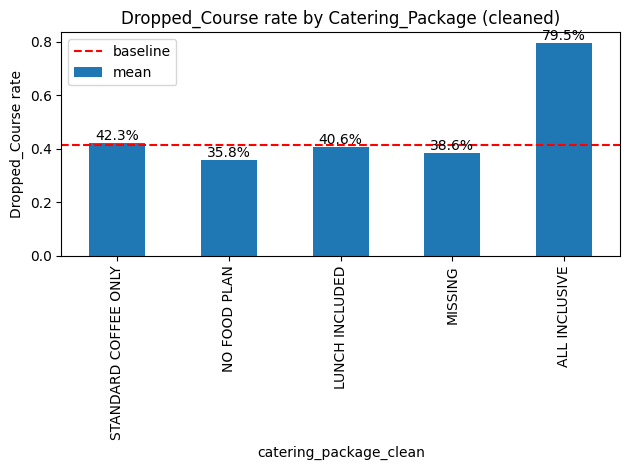

In [71]:
col = "Catering_Package"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["catering_package_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["catering_package_clean"].nunique())

rate_by_cat = df.groupby("catering_package_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

**What can you infer about `Catering_Package`?**

1. 321 raw values - 5 real categories after cleaning.
2. Most categories sit close to baseline, besides `ALL INCLUSIVE` that stands out - 79.5% drop rate, almost double baseline - but n=44 (0.1%) is too small to trust.

**Decision:** one hot encode all categories. perhaps drop `ALL INCLUSIVE` only in revisit.

### Lanyard_Color

raw unique: 240 -> cleaned unique: 5
                         mean  count   pct
lanyard_color_clean                       
BLUE                 0.413588  35076  55.3
BLACK                0.414583  14839  23.4
RED                  0.415902   7194  11.3
ORANGE               0.416552   3637   5.7
GREEN                0.416851   2718   4.3


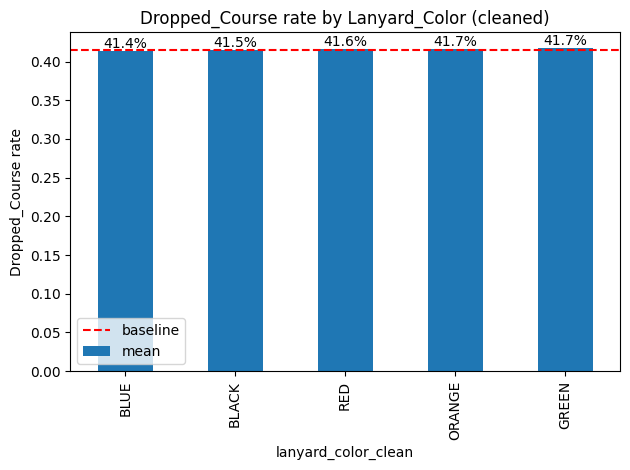

In [72]:
col = "Lanyard_Color"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["lanyard_color_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["lanyard_color_clean"].nunique())

rate_by_cat = df.groupby("lanyard_color_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

**What can you infer about `Lanyard_Color`?**

1. 240 raw values - 5 real unique colors after cleaning.
2. Behaves similar to `Welcome_Gift_Type` - no benefit to this variable.

**Decision:** drop `Lanyard_Color`.

## ID variables

### Company_ID

             mean  count   pct
missing  0.424848  60344  95.1
present  0.212179   3120   4.9


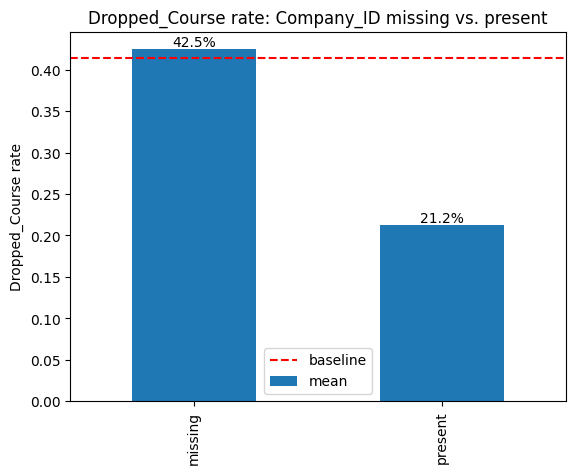

In [73]:
has_company = df['Company_ID'].notna()
rate_by_flag = df.groupby(has_company)[TARGET].agg(['mean', 'count'])
rate_by_flag.index = ['missing', 'present']
rate_by_flag["pct"] = (rate_by_flag["count"] / len(df) * 100).round(1)
print(rate_by_flag)

ax = rate_by_flag['mean'].plot(kind='bar')
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_flag["mean"]])
plt.axhline(baseline_rate, color='red', linestyle='--', label='baseline')
plt.title(f"{TARGET} rate: Company_ID missing vs. present")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

In [74]:
present = df[df["Company_ID"].notna()] # Filter out rows where Company_ID is missing
base = df["Dropped_Course"].mean() # Calculate the overall average drop rate

counts = present["Company_ID"].value_counts() # Count enrollments per company
print(counts.describe())

top = (present.groupby("Company_ID")[TARGET]
       .agg(["mean", "count"])
       .sort_values("count", ascending=False)
       .head(5))
print("Top 5 companies by enrollment count:")
print(top)


count    184.000000
mean      16.956522
std       66.043439
min        1.000000
25%        1.000000
50%        2.000000
75%       10.000000
max      801.000000
Name: count, dtype: float64
Top 5 companies by enrollment count:
                mean  count
Company_ID                 
5181.0      0.089888    801
5013.0      0.655431    267
5194.0      0.110048    209
5119.0      0.220690    145
5185.0      0.069565    115


1. 184 companies have a known `Company_ID`. Median company has only 2 enrollments.
2. So before ranking companies by drop rate, lets set minimum enrollment count per company and set to n>=30 enrollemnts, using Central Limit Theorom

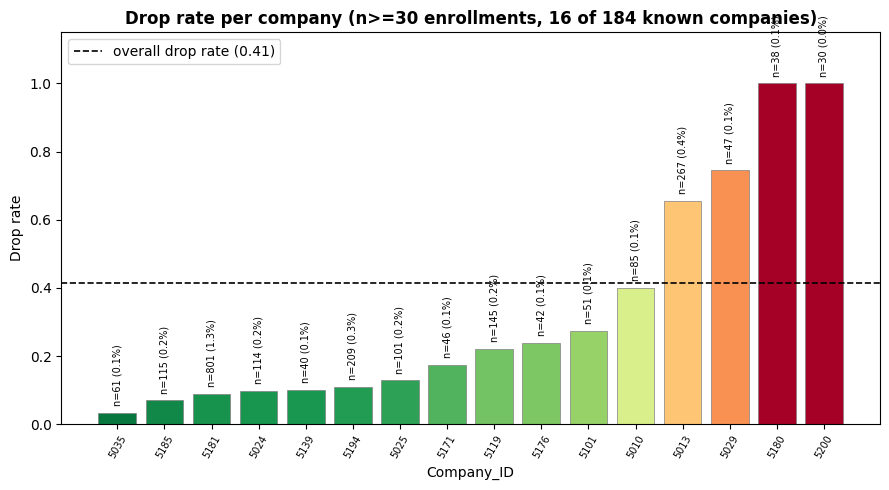

spread across companies with n>=30: min 0.03278688524590164 max 1.0 std 0.33048981716937365


In [75]:
big = counts[counts >= 30].index
r = (present[present["Company_ID"].isin(big)]
     .groupby("Company_ID")[TARGET]
     .agg(["mean", "count"])
     .sort_values("mean"))
r["pct"] = (r["count"] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn_r(r["mean"].values)
ax.bar(range(len(r)), r["mean"].values, color=colors, edgecolor="gray", lw=0.5)
ax.axhline(base, ls="--", color="black", lw=1.2,
           label=f"overall drop rate ({base:.2f})")

for i, (idx, row) in enumerate(r.iterrows()):
    ax.text(i, row["mean"] + 0.02, f"n={int(row['count'])} ({row['pct']}%)",
            ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(range(len(r)))
ax.set_xticklabels([int(x) for x in r.index], rotation=60, fontsize=7)
ax.set_ylabel("Drop rate"); ax.set_xlabel("Company_ID"); ax.set_ylim(0, 1.15)
ax.set_title(f"Drop rate per company (n>=30 enrollments, {len(big)} of {present['Company_ID'].nunique()} known companies)",
             fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

print("spread across companies with n>=30: min", r["mean"].min(), "max", r["mean"].max(), "std", r["mean"].std())

**What can you infer about `Company_ID`?**

1. More than 95% rows are missing `Company_ID`. 
2. We also see the drop rate for the missing is around baseline (42%), while rows that have a `Company_ID` are much less likely to drop (21%) - half the amount. 
3. Only 16 of the 184 known companies have n>=30 enrollments. Among them, drop rates range from 3.3% to 100%.

**Decision:** 
1. Keep a `has_company_id` flag (present vs. missing) to improve model accuracy.
2. One-hot encode the 16 companies with n>=30, and fold the remaining 168 small companies into OTHER - same pattern as `Origin_Country`.

### Client_ID

In [76]:
col = "Client_ID"
print("unique:", df[col].nunique(), "of", len(df), "rows")
print("missing:", df[col].isna().sum())

rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
print(rate_by_missing)

unique: 63464 of 63464 rows
missing: 0
               mean  count
Client_ID                 
False      0.414392  63464


**What can you infer about `Client_ID`?**

1. Unique on every one of the 63,464 rows.
2. Obviously a variable to reduct.

**Decision:** drop `Client_ID`.

### Agent_ID

             mean  count   pct
missing  0.335094  11173  17.6
present  0.431336  52291  82.4


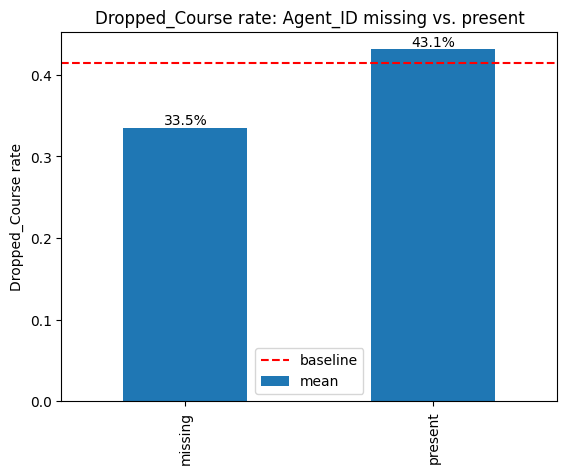

In [77]:
has_agent = df["Agent_ID"].notna()
rate_by_flag = df.groupby(has_agent)[TARGET].agg(["mean", "count"])
rate_by_flag.index = ["missing", "present"]
rate_by_flag["pct"] = (rate_by_flag["count"] / len(df) * 100).round(1)
print(rate_by_flag)

ax = rate_by_flag["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_flag["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate: Agent_ID missing vs. present")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

203 agents have a known `Agent_ID`, but the median agent closed only 17 enrollments and the 75th percentile is 72 — many agents are small. As with `Company_ID`, we need a minimum enrollment count per agent before comparing drop rates, so a single agent's rate isn't just noise from a handful of outcomes.

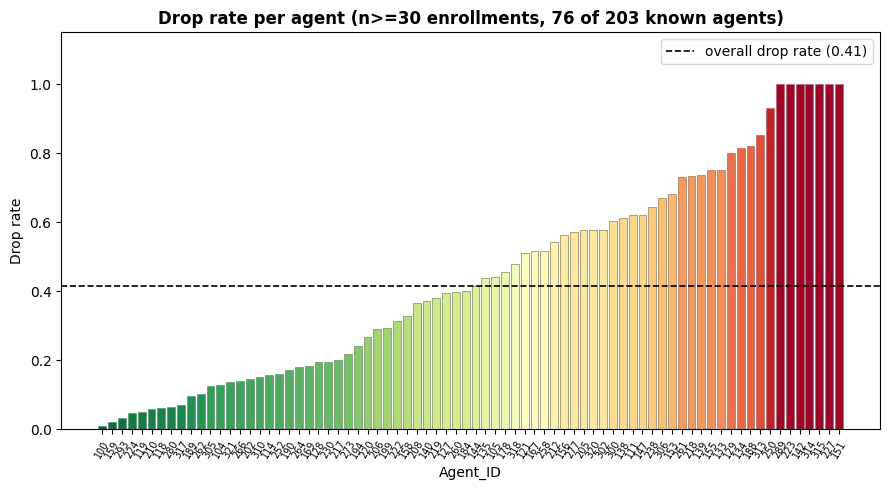

spread across agents with n>=30: min 0.01020408163265306 max 1.0 std 0.300800772148699


In [78]:
present = df[df["Agent_ID"].notna()]
counts = present["Agent_ID"].value_counts()
big = counts[counts >= 30].index
r = (present[present["Agent_ID"].isin(big)]
     .groupby("Agent_ID")[TARGET]
     .agg(["mean", "count"])
     .sort_values("mean"))
r["pct"] = (r["count"] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn_r(r["mean"].values)
ax.bar(range(len(r)), r["mean"].values, color=colors, edgecolor="gray", lw=0.5)
ax.axhline(baseline_rate, ls="--", color="black", lw=1.2, label=f"overall drop rate ({baseline_rate:.2f})")
ax.set_xticks(range(len(r)))
ax.set_xticklabels([int(x) for x in r.index], rotation=60, fontsize=7)
ax.set_ylabel("Drop rate")
ax.set_xlabel("Agent_ID")
ax.set_ylim(0, 1.15)
ax.set_title(f"Drop rate per agent (n>=30 enrollments, {len(big)} of {present['Agent_ID'].nunique()} known agents)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("spread across agents with n>=30: min", r["mean"].min(), "max", r["mean"].max(), "std", r["mean"].std())

**What can you infer about `Agent_ID`?**

1. 17.6% of rows have no `Agent_ID`. 
2. Unlike `Company_ID`, this points the other way - missing rows have a lower drop rate (33.5%) than rows with a known agent (43.1%). Meaning, a process that includes a known agent is associated with higher risk, not lower.
2. 76 of the 203 known agents have n>=30 enrollments. Among them, drop rates range from 1.0% to 100%. 

**Decision:** Similar to `Company_id`.
1. Keep has_agent_id as its own flag. 
2. For the agent identity itself, one-hot encode the 76 agents with n>=30, and fold the remaining 127 small agents into OTHER.

# Part B - Feature Engineering, Outlier Analysis

In [79]:
is_prepaid = df["payment_terms_clean"] == "PREPAID NONREFUNDABLE"
is_affiliated = df["enrollment_type_clean"] == "AFFILIATED ADMISSION"
exclude_payment_terms = is_prepaid & ~is_affiliated
exclude_client_category = df["client_category_clean"] == "UNKNOWN"
exclude_mask = exclude_payment_terms | exclude_client_category

print(f"excluding {exclude_payment_terms.sum()} rows: Payment_Terms/Enrollment_Type deterministic slice")
print(f"excluding {exclude_client_category.sum()} rows: Client_Category == UNKNOWN")
print(f"total excluded: {exclude_mask.sum()} of {len(df)} ({exclude_mask.mean():.1%})")

df_model = df.loc[~exclude_mask].copy()
print("remaining rows:", len(df_model))

excluding 9695 rows: Payment_Terms/Enrollment_Type deterministic slice
excluding 2 rows: Client_Category == UNKNOWN
total excluded: 9697 of 63464 (15.3%)
remaining rows: 53767


In [80]:
daily_tuition_clean = df_model["Daily_Tuition_Cost"].where(df_model["Daily_Tuition_Cost"] != 5400)

registration_days_imputed = df_model["Registration_Days_Before"].fillna(df_model["Registration_Days_Before"].median())
students_count_imputed = df_model["students_count_clean"].fillna(df_model["students_count_clean"].median())
practical_hours_imputed = df_model["practical_hours_clean"].fillna(df_model["practical_hours_clean"].median())
daily_tuition_imputed = daily_tuition_clean.fillna(daily_tuition_clean.median())

print("median fill values:")
print("  Registration_Days_Before:", df_model["Registration_Days_Before"].median())
print("  Students_Count:", df_model["students_count_clean"].median())
print("  Practical_Hours:", df_model["practical_hours_clean"].median())
print("  Daily_Tuition_Cost:", daily_tuition_clean.median())

median fill values:
  Registration_Days_Before: 53.0
  Students_Count: 0.0
  Practical_Hours: 1.0
  Daily_Tuition_Cost: 95.2


In [81]:
had_prior_dropout = (df_model["Prev_Course_Dropouts"] >= 1).astype(int)
attended_before = (df_model["Prev_Course_Attended"] >= 1).astype(int)
has_waited = (df_model["Waiting_List_Days"] > 0).astype(int)
has_observers = (df_model["Observers_Count"] > 0).astype(int)
has_support_ticket = (df_model["Pre_Course_Supports_Tickets"] > 0).astype(int)
is_zero_cost = (daily_tuition_clean == 0).astype(int)
has_company_id = df_model["Company_ID"].notna().astype(int)
has_agent_id = df_model["Agent_ID"].notna().astype(int)

In [82]:
import numpy as np

registration_changes_group = pd.Series(
    np.select(
        [df_model["Registration_Changes"] == 0, df_model["Registration_Changes"] == 1],
        ["0", "1"],
        default="2+",
    ),
    index=df_model.index,
)
registration_changes_group = pd.Categorical(registration_changes_group, categories=["0", "1", "2+"])

lab_config_full = df["Requested_Lab_Config"].where(df["Requested_Lab_Config"].notna(), "MISSING")
top_lab_configs = lab_config_full[lab_config_full != "MISSING"].value_counts().head(6).index.tolist()
print("Requested_Lab_Config kept categories:", top_lab_configs)
lab_config_clean = df_model["Requested_Lab_Config"].where(df_model["Requested_Lab_Config"].notna(), "MISSING")
lab_config_grouped = lab_config_clean.where(lab_config_clean.isin(top_lab_configs + ["MISSING"]), "OTHER")
lab_config_grouped = pd.Categorical(lab_config_grouped, categories=top_lab_configs + ["OTHER", "MISSING"])

country_pct = df.loc[df["country_clean"] != "MISSING", "country_clean"].value_counts(normalize=True) * 100
top_countries = list(country_pct[country_pct >= 4.0].index)
print("Origin_Country kept categories (>=4% of rows):", top_countries)
country_grouped = df_model["country_clean"].where(df_model["country_clean"].isin(top_countries + ["MISSING"]), "OTHER")
country_grouped = pd.Categorical(country_grouped, categories=top_countries + ["OTHER", "MISSING"])
company_counts = df["Company_ID"].value_counts()
big_companies = [str(int(v)) for v in company_counts[company_counts >= 30].index]
print(f"Company_ID: {len(big_companies)} companies with n>=30")
company_grouped = df_model["Company_ID"].apply(lambda v: "OTHER" if pd.isna(v) else str(int(v)))
company_grouped = company_grouped.where(company_grouped.isin(big_companies), "OTHER")
company_grouped = pd.Categorical(company_grouped, categories=big_companies + ["OTHER"])

agent_counts = df["Agent_ID"].value_counts()
big_agents = [str(int(v)) for v in agent_counts[agent_counts >= 30].index]
print(f"Agent_ID: {len(big_agents)} agents with n>=30")
agent_grouped = df_model["Agent_ID"].apply(lambda v: "OTHER" if pd.isna(v) else str(int(v)))
agent_grouped = agent_grouped.where(agent_grouped.isin(big_agents), "OTHER")
agent_grouped = pd.Categorical(agent_grouped, categories=big_agents + ["OTHER"])

one_hot_df = pd.get_dummies(
    pd.DataFrame({
        "registration_changes": registration_changes_group,
        "requested_lab_config": lab_config_grouped,
        "origin_country": country_grouped,
        "client_category": df_model["client_category_clean"],
        "enrollment_type": df_model["enrollment_type_clean"],
        "submission_source": df_model["submission_source_clean"],
        "catering_package": df_model["catering_package_clean"],
        "payment_terms": df_model["payment_terms_bucket"],
        "company_id_group": company_grouped,
        "agent_id_group": agent_grouped,
    }, index=df_model.index),
    prefix_sep="__",
).astype(int)

print("one-hot columns:", one_hot_df.shape[1])
print("company_id_group columns:", sum(1 for c in one_hot_df.columns if c.startswith("company_id_group__")))
print("agent_id_group columns:", sum(1 for c in one_hot_df.columns if c.startswith("agent_id_group__")))

Requested_Lab_Config kept categories: ['Standard PC (Windows)', 'Linux Workstation', 'Dual Monitor Setup', 'MacOS Station', 'Laptop Docking Station', 'High-GPU Unit']
Origin_Country kept categories (>=4% of rows): ['PRT', 'FRA', 'DEU', 'ESP', 'GBR', 'ITA']
Company_ID: 16 companies with n>=30
Agent_ID: 76 agents with n>=30
one-hot columns: 139
company_id_group columns: 17
agent_id_group columns: 77


In [83]:
course_start_days = (df_model["Course_Start_Date"] - df_model["Course_Start_Date"].min()).dt.days

numeric_df = pd.DataFrame({
    "had_prior_dropout": had_prior_dropout,
    "attended_before": attended_before,
    "registration_days_before": registration_days_imputed,
    "waiting_list_days": df_model["Waiting_List_Days"],
    "has_waited": has_waited,
    "has_support_ticket": has_support_ticket,
    "professionals_count": df_model["Professionals_Count"],
    "students_count": students_count_imputed,
    "has_observers": has_observers,
    "practical_hours": practical_hours_imputed,
    "theory_hours": df_model["Theory_Hours"],
    "daily_tuition_cost": daily_tuition_imputed,
    "is_zero_cost": is_zero_cost,
    "returning_client": df_model["Returning_Client"],
    "has_company_id": has_company_id,
    "has_agent_id": has_agent_id,
    "course_start_days": course_start_days,
})

X = pd.concat([numeric_df, one_hot_df], axis=1)
y = df_model[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
null_counts = X.isna().sum()
print("columns with nulls (should be empty):")
print(null_counts[null_counts > 0])
print("non-numeric dtypes (should be empty):")
print(X.dtypes[X.dtypes == "object"])
print(f"row check: {len(df)} - {exclude_mask.sum()} excluded = {len(df) - exclude_mask.sum()} == {len(X)}")

X shape: (53767, 156)
y shape: (53767,)
columns with nulls (should be empty):
Series([], dtype: int64)
non-numeric dtypes (should be empty):
Series([], dtype: object)
row check: 63464 - 9697 excluded = 53767 == 53767


In [84]:
raw_cardinality = {
    "Origin_Country": df["Origin_Country"].nunique(),
    "Client_Category": df["Client_Category"].nunique(),
    "Payment_Terms": df["Payment_Terms"].nunique(),
    "Enrollment_Type": df["Enrollment_Type"].nunique(),
    "Submission_Source": df["Submission_Source"].nunique(),
    "Catering_Package": df["Catering_Package"].nunique(),
    "Requested_Lab_Config": df["Requested_Lab_Config"].nunique(),
    "Company_ID": df["Company_ID"].nunique(),
    "Agent_ID": df["Agent_ID"].nunique(),
}
final_onehot_prefixes = {
    "Origin_Country": "origin_country__",
    "Client_Category": "client_category__",
    "Payment_Terms": "payment_terms__",
    "Enrollment_Type": "enrollment_type__",
    "Submission_Source": "submission_source__",
    "Catering_Package": "catering_package__",
    "Requested_Lab_Config": "requested_lab_config__",
    "Company_ID": "company_id_group__",
    "Agent_ID": "agent_id_group__",
}

print(f"{'column':<22}{'raw unique':>12}{'final one-hot cols':>22}")
for name, prefix in final_onehot_prefixes.items():
    final_n = sum(1 for c in one_hot_df.columns if c.startswith(prefix))
    print(f"{name:<22}{raw_cardinality[name]:>12}{final_n:>22}")

print()
print("total one-hot columns:", one_hot_df.shape[1])
print("total feature columns (X):", X.shape[1])
print(f"rows per feature: {X.shape[0] / X.shape[1]:.0f}")

column                  raw unique    final one-hot cols
Origin_Country                 721                     8
Client_Category                505                     7
Payment_Terms                  236                     3
Enrollment_Type                298                     5
Submission_Source              328                     6
Catering_Package               321                     5
Requested_Lab_Config             8                     8
Company_ID                     184                    17
Agent_ID                       203                    77

total one-hot columns: 139
total feature columns (X): 156
rows per feature: 345


## Summary

**1. Stage 1 decision → Stage 2 transform, grouped by transform type**

- **Grouped into buckets (0/1/2+):** `Registration_Changes`, `Payment_Terms` (3-way: `PAY UPON START`/`PREPAID NONREFUNDABLE`/`OTHER`).

- **Binary presence/threshold flag added:** `had_prior_dropout`, `attended_before`, `has_waited`, `has_observers`, `has_support_ticket`, `is_zero_cost`, `has_company_id`, `has_agent_id`.

- **Excluded** — columns: `Client_ID`, `Welcome_Gift_Type`, `Lanyard_Color`, `Physical_Course_Kits`, `Assigned_Lab_Config` (no signal / leakage). Rows: 9,697 total across 2 rules (see Outlier Analysis below).

- **One-hot encoded** (top categories + `OTHER`/`MISSING` where cardinality required it): `Requested_Lab_Config`, `Origin_Country`, `Client_Category`, `Enrollment_Type`, `Submission_Source`, `Catering_Package`, `Payment_Terms`, `Company_ID`, `Agent_ID`, `Registration_Changes`.

- **Missing values filled with median** (not mean — Stage 1 showed these are right-skewed): `Registration_Days_Before` → 53.0, `Students_Count` → 0.0, `Practical_Hours` → 1.0, `Daily_Tuition_Cost` → 95.2.

- **Kept unchanged as numeric predictors:** `Professionals_Count`, `Theory_Hours`, `Returning_Client`, `Waiting_List_Days`, `Daily_Tuition_Cost` (raw value, alongside its flag), `Course_Start_Date` → `course_start_days`.

**2. Outlier Analysis** (all visualized in Stage 1 — see each variable's section above; Stage 2 only implements the decision)

- `Students_Count` = 9999 (n=55) — sentinel, recoded to `NaN`, median-filled.

- `Practical_Hours` ∈ {-5, -1, 5000, 10000} (n=117) — sentinels, recoded to `NaN`, median-filled.

- `Daily_Tuition_Cost` = 5400 — outlier value, recoded to `NaN`, median-filled.

- `Payment_Terms` = `PREPAID NONREFUNDABLE` + non-affiliated `Enrollment_Type` (n=9,695, 100% drop rate) — too deterministic to trust as a learnable pattern, row excluded.

- `Client_Category` = `UNKNOWN` (n=2) — negligible sample, row excluded.

**3. Reductions (curse of dimensionality)**

Two methods, combined: **EDA-based** (Stage 1 text cleaning collapsed raw junk values — e.g. `Origin_Country` 721→154, `Client_Category` 505→8) and **statistics-based** (Stage 2 keeps only categories with enough `n` to trust — `Company_ID` 184→17, `Agent_ID` 203→77, `Origin_Country` 154→8 — folding the rest into `OTHER`). See the printed table above for the full column-by-column breakdown.

---

**#note:** perhaps revisit the right tails for `Theory_Hours` (max 41h, n=1) and `Registration_Days_Before` (max 629 days, n=16) — currently left untouched, no row exclusion or capping applied.

In [85]:
X.head()

,had_prior_dropout,attended_before,registration_days_before,waiting_list_days,has_waited,has_support_ticket,professionals_count,students_count,has_observers,practical_hours,...,agent_id_group__188,agent_id_group__156,agent_id_group__155,agent_id_group__151,agent_id_group__210,agent_id_group__202,agent_id_group__194,agent_id_group__310,agent_id_group__305,agent_id_group__OTHER
0,0,0,257.0,0,0,0,2,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,257.0,0,0,0,1,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,257.0,0,0,0,1,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,257.0,0,0,0,2,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,257.0,0,0,0,1,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0


# Part C - Model Training & Hyperparameter Tuning

Three different models are tried on the data (`X`/`y`): Logistic Regression, Random Forest, XGBoost.

For Part C, we ran Claude's /loop autonomous mode with a prompt we designed, which is attached in the report's appendix — stage3_loop_prompt.md.

**What happens, in order:**
1. Set aside 20% of the labeled data untouched, for testing later in Part D.
2. Split the remaining 80% into 5 groups, reused for testing every model the same way.
3. For each model, try ~20-30 different settings and keep whichever one scores best.
4. If any model's score comes out above 0.90, double-check it isn't cheating by leaking the answer somewhere. *suggested by the llm model.

**Double-checking for leaked answers:**
- Confirm `Physical_Course_Kits`, `Assigned_Lab_Config`, `Welcome_Gift_Type`, `Lanyard_Color`, `Client_ID` are not present in the data used to train.
- Confirm the country/company/agent groupings were built only from how often each value appears — never from whether that student actually dropped.

In [86]:
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import loguniform, randint, uniform
from xgboost import XGBClassifier

set_config(transform_output="pandas")
RANDOM_STATE = 42

leak_cols = [c for c in X.columns if any(k in c.lower() for k in
             ["physical_course_kit", "assigned_lab", "welcome_gift", "lanyard", "client_id"])]
print("leakage columns present in X (expect []):", leak_cols)
print("X shape:", X.shape, "| all-numeric:", bool((X.dtypes != object).all()), "| total nulls:", int(X.isna().sum().sum()))
print(f"drop rate on modeling rows: {y.mean():.4f}  (positives={int(y.sum())}, n={len(y)})")
print(f"full-file drop rate (for contrast): {df[TARGET].mean():.4f}")

leakage columns present in X (expect []): []
X shape: (53767, 156) | all-numeric: True | total nulls: 0
drop rate on modeling rows: 0.3088  (positives=16602, n=53767)
full-file drop rate (for contrast): 0.4144


## Step 0 — held-out test split

- `Test_Data_No_Target.csv` has no labels, so a labeled holdout for Part D is carved out of `X`/`y` directly.
- Split keeps the same drop rate in both pieces (`stratify=y`).
- Done before any CV or hyperparameter search.

In [87]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"train pool : {X_train.shape[0]:>6} rows | drop rate {y_train.mean():.4f} | positives {int(y_train.sum())}")
print(f"holdout    : {X_holdout.shape[0]:>6} rows | drop rate {y_holdout.mean():.4f} | positives {int(y_holdout.sum())}")
print("holdout is set aside now and not read again until Part D.")

train pool :  43013 rows | drop rate 0.3088 | positives 13281
holdout    :  10754 rows | drop rate 0.3088 | positives 3321
holdout is set aside now and not read again until Part D.


## Step 1 — shared cross-validation

- The train pool is split into 5 equal groups.
- Each of the 5 rounds trains on 4 groups and tests on the 1 left out; every group gets a turn being tested on.
- The 5 test scores are averaged into one overall score per model.
- The same 5 groups are reused for all three models, so their scores are directly comparable.
- Each round's train-set score is also recorded alongside its test score, to check for overfitting later.

In [88]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

def cv_report(search, name):
    bi = search.best_index_
    r = search.cv_results_
    mean_cv, std_cv = r["mean_test_score"][bi], r["std_test_score"][bi]
    mean_tr = r["mean_train_score"][bi]
    train_full = roc_auc_score(y_train, search.best_estimator_.predict_proba(X_train)[:, 1])
    print(f"[{name}] best params: {search.best_params_}")
    print(f"[{name}] mean CV AUC        = {mean_cv:.4f} +/- {std_cv:.4f}")
    print(f"[{name}] mean train-fold AUC = {mean_tr:.4f}  | gap (train-fold - CV) = {mean_tr - mean_cv:.4f}")
    print(f"[{name}] full train-pool AUC (resubstitution) = {train_full:.4f}")
    out = {"model": name, "best_params": search.best_params_, "CV_AUC_mean": mean_cv,
           "CV_AUC_std": std_cv, "train_fold_AUC": mean_tr, "gap": mean_tr - mean_cv,
           "train_full_AUC": train_full}
    results.append(out)
    return out

## Model 1 — Logistic Regression 

**Hyperparameters tried:**
- `C` — how tightly the line fits the data it's given. Larger value fits more aggressively.
- `penalty` (`l1` or `l2`).

In [89]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE)),
])
logreg_space = {"clf__C": loguniform(1e-3, 1e2), "clf__penalty": ["l1", "l2"]}
logreg_search = RandomizedSearchCV(
    logreg_pipe, logreg_space, n_iter=20, scoring="roc_auc", cv=skf,
    n_jobs=-1, random_state=RANDOM_STATE, return_train_score=True, refit=True)
logreg_search.fit(X_train, y_train)
logreg_best = logreg_search.best_estimator_
_ = cv_report(logreg_search, "LogisticRegression")

[LogisticRegression] best params: {'clf__C': np.float64(0.0745934328572655), 'clf__penalty': 'l1'}
[LogisticRegression] mean CV AUC        = 0.8539 +/- 0.0051
[LogisticRegression] mean train-fold AUC = 0.8569  | gap (train-fold - CV) = 0.0029
[LogisticRegression] full train-pool AUC (resubstitution) = 0.8567


- Settings chosen: `C = 0.075`, `penalty = l1`.
- Score on unseen quiz-groups: 0.854 (± 0.005).
- Score on the data it studied: 0.857.

## Model 2 — Random Forest

**Hyperparameters tried:**
- `n_estimators` — how many trees vote together. More trees = more stable answer.
- `max_depth` — how many yes/no questions each tree can ask. Deeper = can spot more complex patterns, but more likely to memorize.
- `min_samples_leaf` — how many rows are left in a group by the time the tree reaches its final answer. Higher = fewer coincidences mistaken for real patterns.
- `max_features` — how many columns each tree is even allowed to look at. Lower = trees disagree more with each other, which helps when averaging their votes.

In [90]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
rf_space = {
    "n_estimators": randint(200, 500),
    "max_depth": [None, 8, 12, 16, 24],
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
}
rf_search = RandomizedSearchCV(
    rf, rf_space, n_iter=20, scoring="roc_auc", cv=skf,
    n_jobs=-1, random_state=RANDOM_STATE, return_train_score=True, refit=True)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
_ = cv_report(rf_search, "RandomForest")

[RandomForest] best params: {'max_depth': 24, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 351}
[RandomForest] mean CV AUC        = 0.9223 +/- 0.0034
[RandomForest] mean train-fold AUC = 0.9673  | gap (train-fold - CV) = 0.0450
[RandomForest] full train-pool AUC (resubstitution) = 0.9680


- Settings chosen: 351 trees, `max_depth = 24`, `min_samples_leaf = 8`, `max_features = 0.5`.
- Score on unseen quiz-groups: 0.922 (± 0.003).
- Score on the data it studied: 0.967.

## Model 3 — XGBoost

**Hyperparameters tried:**
- `max_depth`
- `colsample_bytree` — same is `max_features`
- `learning_rate` — how big a correction each new tree is allowed to make. Smaller = slower, more cautious learning.
- `n_estimators` — how many trees get built in sequence.
- `subsample` — the fraction of orders each tree trains on.
- `reg_alpha` / `reg_lambda` — direct penalties that discourage leaning too hard on any single clue.

In [91]:
xgb = XGBClassifier(objective="binary:logistic", eval_metric="auc",
                    tree_method="hist", random_state=RANDOM_STATE, n_jobs=1)
xgb_space = {
    "max_depth": randint(3, 13),
    "learning_rate": loguniform(1e-2, 3e-1),
    "n_estimators": randint(300, 900),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": loguniform(1e-3, 1e1),
    "reg_lambda": loguniform(1e-3, 1e1),
}
xgb_search = RandomizedSearchCV(
    xgb, xgb_space, n_iter=30, scoring="roc_auc", cv=skf,
    n_jobs=-1, random_state=RANDOM_STATE, return_train_score=True, refit=True)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
_ = cv_report(xgb_search, "XGBoost")

X_tr_es, X_val_es, y_tr_es, y_val_es = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)
es_params = {k: v for k, v in xgb_search.best_params_.items() if k != "n_estimators"}
xgb_es = XGBClassifier(objective="binary:logistic", eval_metric="auc", tree_method="hist",
                       random_state=RANDOM_STATE, n_jobs=1, n_estimators=2000,
                       early_stopping_rounds=50, **es_params)
xgb_es.fit(X_tr_es, y_tr_es, eval_set=[(X_val_es, y_val_es)], verbose=False)
print(f"early stopping: best_iteration = {xgb_es.best_iteration} of 2000 max (patience=50)")
print(f"early-stopped best val AUC = {xgb_es.best_score:.4f}")
print(f"random-search chosen n_estimators = {xgb_search.best_params_['n_estimators']}")

[XGBoost] best params: {'colsample_bytree': np.float64(0.7024273291045295), 'learning_rate': np.float64(0.011474276591948267), 'max_depth': 12, 'n_estimators': 853, 'reg_alpha': np.float64(0.05719341217670732), 'reg_lambda': np.float64(0.0064102771881101635), 'subsample': np.float64(0.9583054382694077)}
[XGBoost] mean CV AUC        = 0.9303 +/- 0.0031
[XGBoost] mean train-fold AUC = 0.9874  | gap (train-fold - CV) = 0.0571
[XGBoost] full train-pool AUC (resubstitution) = 0.9842
early stopping: best_iteration = 1132 of 2000 max (patience=50)
early-stopped best val AUC = 0.9301
random-search chosen n_estimators = 853


- Settings chosen: `max_depth = 12`, `learning_rate = 0.011`, 853 trees, `subsample = 0.96`, `colsample_bytree = 0.70`.
- Score on unseen quiz-groups: 0.930 (± 0.003).
- Score on the data it studied: 0.987.

`early_stopping_rounds` - a separate run kept adding trees while watching a set-aside slice, and stopped once more trees stopped helping — it stopped at tree #1,132, scoring 0.930, matching the quiz score exactly.

## Model comparison summary

In [92]:
summary = pd.DataFrame(results)[
    ["model", "CV_AUC_mean", "CV_AUC_std", "train_fold_AUC", "gap"]
].round(4)
print(summary.to_string(index=False))
print()
for r in results:
    print(f"{r['model']}: {r['best_params']}")

fitted_models = {"LogisticRegression": logreg_best, "RandomForest": rf_best, "XGBoost": xgb_best}
print()
print("fitted .best_estimator_ objects ready for Part D:", list(fitted_models.keys()))
print(f"holdout reserved & untouched: X_holdout {X_holdout.shape}, positives {int(y_holdout.sum())}")

             model  CV_AUC_mean  CV_AUC_std  train_fold_AUC    gap
LogisticRegression       0.8539      0.0051          0.8569 0.0029
      RandomForest       0.9223      0.0034          0.9673 0.0450
           XGBoost       0.9303      0.0031          0.9874 0.0571

LogisticRegression: {'clf__C': np.float64(0.0745934328572655), 'clf__penalty': 'l1'}
RandomForest: {'max_depth': 24, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 351}
XGBoost: {'colsample_bytree': np.float64(0.7024273291045295), 'learning_rate': np.float64(0.011474276591948267), 'max_depth': 12, 'n_estimators': 853, 'reg_alpha': np.float64(0.05719341217670732), 'reg_lambda': np.float64(0.0064102771881101635), 'subsample': np.float64(0.9583054382694077)}

fitted .best_estimator_ objects ready for Part D: ['LogisticRegression', 'RandomForest', 'XGBoost']
holdout reserved & untouched: X_holdout (10754, 156), positives 3321


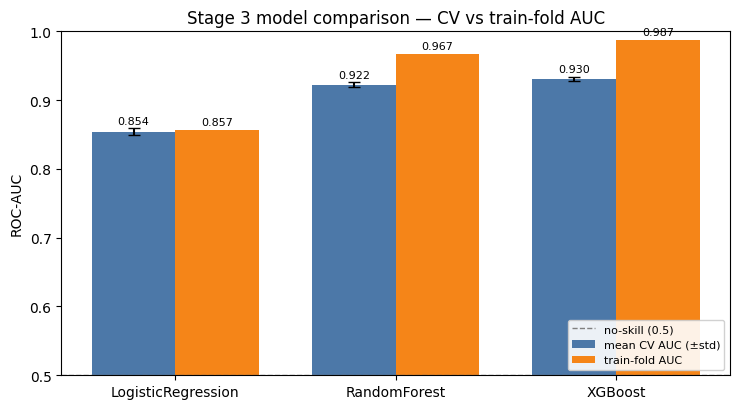

In [93]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
xpos = np.arange(len(summary))
w = 0.38
b1 = ax.bar(xpos - w / 2, summary["CV_AUC_mean"], w, yerr=summary["CV_AUC_std"],
            capsize=4, label="mean CV AUC (±std)", color="#4C78A8")
b2 = ax.bar(xpos + w / 2, summary["train_fold_AUC"], w,
            label="train-fold AUC", color="#F58518")
ax.axhline(0.5, ls="--", lw=1, color="grey", label="no-skill (0.5)")
ax.set_xticks(xpos)
ax.set_xticklabels(summary["model"])
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.5, 1.0)
ax.set_title("Stage 3 model comparison — CV vs train-fold AUC")
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

## Summery

**Setup**
- 80/20 split - while keeping drop ratios between splitted data. Holdout split saved for part D
- Cross-Validation with K = 5.

**Results** — mean CV AUC ± std | train-fold AUC | gap
- Logistic Regression — 0.854 ± 0.005 | 0.857 | 0.003.
- Random Forest — 0.922 ± 0.003 | 0.967 | 0.045.
- XGBoost — 0.930 ± 0.003 | 0.987 | 0.057. 

**How we interpret the results, considering bias-variance**:
- Logistic Regression — train AUC (studied-score) and CV AUC (quiz-score) were basically identical (0.857 vs 0.854), indicating no overfitting and consistent performance on unseen data. That consistency is also a sign the model may be too simple to capture more complex patterns.

- Random Forest - train AUC and CV AUC show a 0.045 gap (0.967 vs 0.922), about 13x the fold std of 0.0034, indicating possible overfitting. However, the low fold-to-fold std means that score is consistent across different held-out groups, confirming the overfitting is a stable, bounded effect rather than one unreliable fold pulling the average.

- XGBoost — train AUC and CV AUC show a 0.057 gap (0.987 vs 0.930), about 18x the fold std, indicating the largest overfitting of the three models. But the score is stable across folds, and a separate `early_stopping_rounds` run reaches the same 0.930 validation AUC — confirming the overfitting is bounded and the score itself is accurate, not exaggerated - not a "too good to be true case".

**Are the results too good? Perhaps we had a slip?** (both tree models pass 0.90):
- The known leakage-risk columns (`Physical_Course_Kits, Assigned_Lab_Config, Welcome_Gift_Type, Lanyard_Color, Client_ID`) are confirmed absent from X.

- The country/company/agent groupings are built purely from how often each value appears, never from whether the order dropped.

- **We assume that considering the fact the linear baseline already reaches 0.854, so the trees' 0.92-0.93 is an interaction lift on genuine signal, not a jump from one leaked column.**


# Part D — Model Evaluation & Results Analysis 

## Section 1 — Holdout confusion matrix & metrics

Confusion matrix and 5 metrics for each model, computed once on `X_holdout` (from part C) at threshold 0.5.

**metrics**:
1. Precision — of predicted dropouts, how many really dropped.
2. Recall — of real dropouts, how many the model caught.
3. F1 — balance between precision and recall.
4. Accuracy — percent of all predictions that were correct.
5. AUC — how well the model ranks dropouts above non-dropouts.

In [94]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score,
)

holdout_probs = {}
holdout_rows = []
n_holdout = len(y_holdout)

for name, model in fitted_models.items():
    proba = model.predict_proba(X_holdout)[:, 1]
    holdout_probs[name] = proba
    pred = (proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_holdout, pred).ravel()
    holdout_rows.append({
        "model": name,
        "TP": tp, "TP_pct": tp / n_holdout * 100,
        "FP": fp, "FP_pct": fp / n_holdout * 100,
        "FN": fn, "FN_pct": fn / n_holdout * 100,
        "TN": tn, "TN_pct": tn / n_holdout * 100,
        "precision": precision_score(y_holdout, pred),
        "recall": recall_score(y_holdout, pred),
        "f1": f1_score(y_holdout, pred),
        "accuracy": accuracy_score(y_holdout, pred),
        "holdout_AUC": roc_auc_score(y_holdout, proba),
    })

holdout_summary = pd.DataFrame(holdout_rows).round(4)
print(f"holdout n = {n_holdout}, positives = {int(y_holdout.sum())} ({y_holdout.mean():.1%})")
print(holdout_summary.to_string(index=False))

holdout n = 10754, positives = 3321 (30.9%)
             model   TP  TP_pct  FP  FP_pct   FN  FN_pct   TN  TN_pct  precision  recall     f1  accuracy  holdout_AUC
LogisticRegression 1896 17.6306 703  6.5371 1425 13.2509 6730 62.5814     0.7295  0.5709 0.6405    0.8021       0.8552
      RandomForest 2348 21.8337 523  4.8633  973  9.0478 6910 64.2552     0.8178  0.7070 0.7584    0.8609       0.9278
           XGBoost 2455 22.8287 532  4.9470  866  8.0528 6901 64.1715     0.8219  0.7392 0.7784    0.8700       0.9334


## Model Selection

XGBoost is the model of choice — set explicitly below rather than picked programmatically, since Part C's CV-AUC ranking and Section 1's holdout-AUC ranking already agree it's on top.

In [101]:
chosen_model_name = "XGBoost"
chosen_model = fitted_models[chosen_model_name]
chosen_proba = holdout_probs[chosen_model_name]

print(f"chosen model: {chosen_model_name}")
print(holdout_summary.set_index("model").loc[chosen_model_name])

chosen model: XGBoost
TP             2455.0000
TP_pct           22.8287
FP              532.0000
FP_pct            4.9470
FN              866.0000
FN_pct            8.0528
TN             6901.0000
TN_pct           64.1715
precision         0.8219
recall            0.7392
f1                0.7784
accuracy          0.8700
holdout_AUC       0.9334
Name: XGBoost, dtype: float64


- XGBoost tops both independent rankings: CV AUC 0.930 (Part C) and holdout AUC 0.9334 (Section 1 above), each ahead of Random Forest (0.922 / 0.9278) and Logistic Regression (0.854 / 0.8552).
- Same order on data the tuning process touched (CV) and data it never touched (holdout) — the agreement is why the pick is safe to hardcode instead of leaving it to `sort_values`.
- XGBoost also has the best recall (0.7392 vs RF's 0.7070), catching 107 more of the 3321 actual dropouts than RF for only 9 extra false positives — relevant since Section 1 flags FN as the costlier error.
- Holdout metrics for the chosen model (from this cell's printed output): precision 0.8219, recall 0.7392, f1 0.7784, accuracy 0.8700.

## Section 5 — SHAP

background sample: 500 rows from X_train
explain sample: 2000 of 10754 holdout rows (capped at 2000 for runtime)


100%|===================| 1999/2000 [05:05<00:00]        

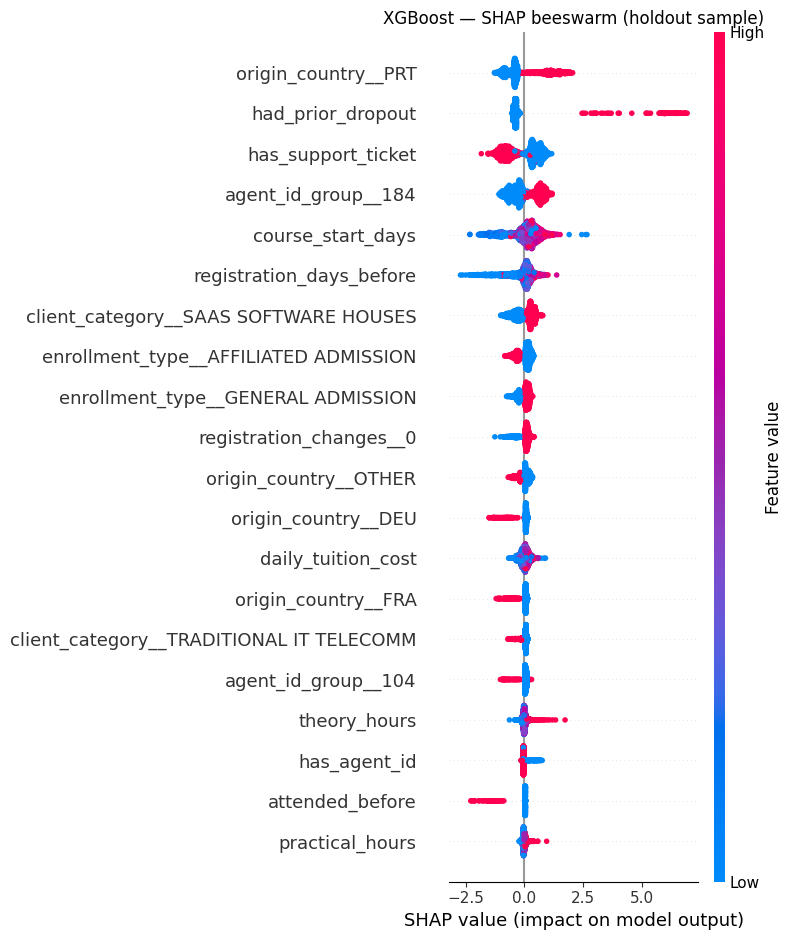

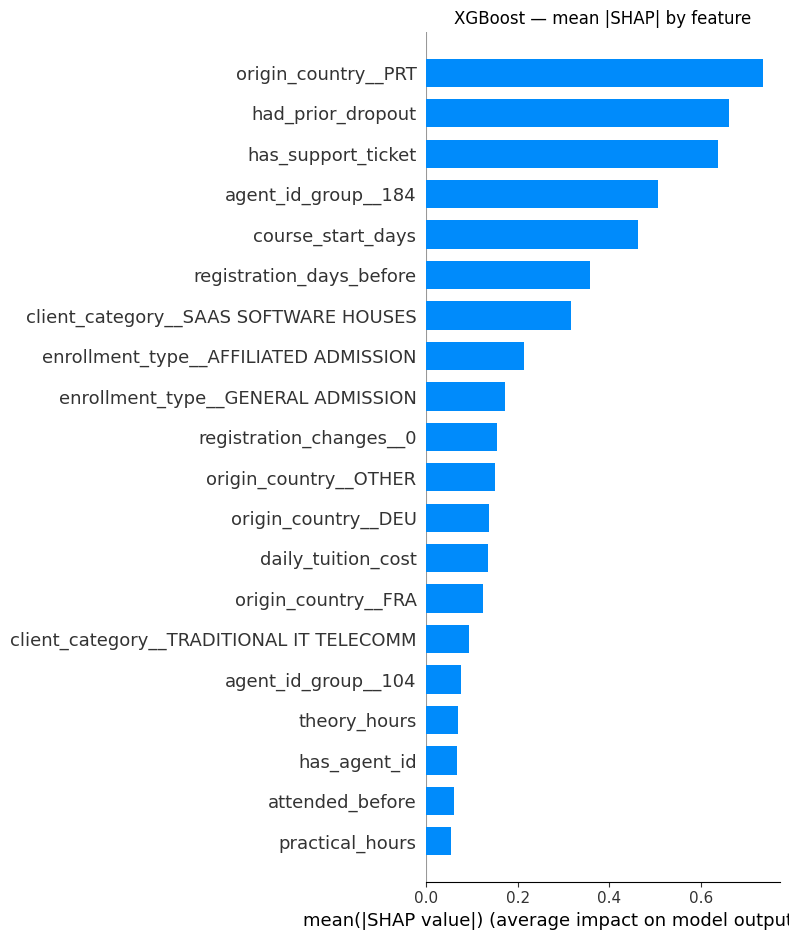

In [106]:
import shap

BACKGROUND_SIZE = 500
EXPLAIN_SAMPLE_SIZE = 2000

background = X_train.sample(n=min(BACKGROUND_SIZE, len(X_train)), random_state=RANDOM_STATE)
explain_idx = X_holdout.sample(n=min(EXPLAIN_SAMPLE_SIZE, len(X_holdout)), random_state=RANDOM_STATE).index
X_explain = X_holdout.loc[explain_idx]

print(f"background sample: {len(background)} rows from X_train")
print(f"explain sample: {len(X_explain)} of {len(X_holdout)} holdout rows (capped at {EXPLAIN_SAMPLE_SIZE} for runtime)")

explainer = shap.TreeExplainer(chosen_model, background)
shap_values = explainer(X_explain)
if shap_values.values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap.summary_plot(shap_values, X_explain, show=False)
plt.title(f"{chosen_model_name} — SHAP beeswarm (holdout sample)")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.title(f"{chosen_model_name} — mean |SHAP| by feature")
plt.tight_layout()
plt.show()

## XGBoost Performence Summery
**Performance on the holdout**
- Catches 74% of real dropouts, correct on 82% of what it flags as dropout — 87% overall accuracy, 0.933 AUC (ranks a real dropout above a non-dropout 93% of the time, at any threshold).
- 866 real dropouts slip through undetected (8.1% of the holdout) — the more expensive mistake here, since a missed dropout means no chance to intervene.

**What drives its decisions (SHAP)**
- Strongest driver: `origin_country__PRT` — being from Portugal.
- Close second: `had_prior_dropout` — a client who dropped before is flagged high-risk, matching Stage 1's finding that drop rate nearly triples after a prior dropout.
- Also meaningful: an open support ticket, one specific agent group, and how far in advance the course starts and was booked.
- In plain terms: the model reads risk mainly from where a client is from, their own history, and who's managing their enrollment — seems logical.


**Something worth noting**
- `origin_country__PRT` is the strongest driver. In part A, we said; "PRT is the largest group by far at 41.6% of all rows and also the highest-risk one... PRT alone could end up dominating the model's use of this feature". Further analysis shows a relation to `Client_Category`: PRT students are mostly Big Tech/Traditional IT (66% combined) and rarely SaaS (17.7%); non-PRT students are the reverse — mostly SaaS (66.1%) and rarely Big Tech (7.2%). Knowing one variable strongly predicts the other. 